## Libraries

In [ ]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    `cudnn.benchmark = False` can cost a bit of throughput - autotuning
    normally picks the fastest kernel for the input shape - an acceptable
    trade for bit-reproducible runs. Determinism is only guaranteed on the
    SAME machine / CUDA / torch version - it is not portable across hardware
    or library versions.

    NOTE: this notebook's training loop batches by indexing GPU-resident
    tensors directly (torch.randperm for shuffling) rather than a
    DataLoader/TensorDataset - there's no multiprocess data-loading worker
    to seed separately, so set_seed()'s torch.manual_seed/cuda.manual_seed_all
    already covers the shuffling order.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
# ---------------------------------------------------------------------------
# Paths - 1 lepton + 2 taus, Run 2 and Run 3 (same source files as
# Final_Notebooks/1L2Tau_Master_Pipeline.ipynb, so the AUC is directly
# comparable to the XGBoost baseline).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/1l2tau/run3")

# Active run used by downstream cells by default.
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product
EVENT_ID_BRANCH = "eventNumber"        # bookkeeping only - NEVER a feature (see BLOCK_SUBSTR)

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy (identical to the XGBoost master
# pipeline, so the two models see the same information).
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)


# ---------------------------------------------------------------------------
# K-fold knobs - shared with every other notebook in this project (see
# assign_folds below). N_OPTUNA_INNER_FOLDS is smaller than N_FOLDS
# deliberately: NN training is far more expensive per-fold than XGBoost's,
# so the Optuna search itself uses fewer folds than the final OOF rotation
# (which always uses the full N_FOLDS) - an efficiency tradeoff, not a
# methodology difference.
# ---------------------------------------------------------------------------

N_FOLDS = 5                # outer K-fold CV - fold = eventNumber % N_FOLDS
N_OPTUNA_TRIALS = 25
N_OPTUNA_INNER_FOLDS = 2   # folds used INSIDE the Optuna search only


## Data Loading Helpers

In [ ]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    
    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME,
                   event_id_branch=EVENT_ID_BRANCH, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - eventNumber : read alongside the features (never used as one - see
        BLOCK_SUBSTR/EVENT_ID_BRANCH) so `assign_folds` can build a
        deterministic fold assignment downstream.
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts + [event_id_branch], cut=preselection, library="pd")
        df["w_phys"] = df["weight"] * df["weights"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


## K-Fold + Weight-Balancing Helper Library

Same 5-fold `eventNumber % N_FOLDS` convention, weight handling (drop
negative-`w_phys` TRAIN/VAL rows, rescale kept rows per-process to the
full-sample signed yield, then `make_fit_weights` per channel/run cell) and
significance objective (`significance_scan`) as
`Final_Notebooks/1L2Tau_Master_Pipeline.ipynb` /
`Final_Notebooks/2L2Tau_Master_Pipeline.ipynb`. `make_fit_weights` is
copy-pasted BYTE-FOR-BYTE from the canonical source
(`Final_Notebooks/PNN.ipynb`) - do not edit this copy without updating every
other copy identically.

`prepare_fold_tensors` is the one NN-specific addition with no XGBoost
equivalent: XGBoost handles NaN natively and needs no scaling, but a
`nn.Linear` can't, so each fold gets its OWN median-imputer + `StandardScaler`
(fit on THAT FOLD's train split only - a fresh fit per fold, since each fold
has a different train partition) plus the `__isnan` missingness flags
(schema fixed globally via `compute_flag_cols`, so every fold's model has
the same input width) and GPU-resident tensor conversion.


In [ ]:
def assign_folds(df, event_col=EVENT_ID_BRANCH, n_folds=N_FOLDS):

    """Deterministic fold assignment: fold = eventNumber % n_folds. The SAME
    rule is applied identically across every notebook/channel/run/track in
    this project, so OOF score arrays stay event-aligned everywhere. Always
    call this exact function on the exact `event_col` - never re-derive
    fold assignment ad hoc per notebook."""

    df = df.copy()
    df["fold"] = (df[event_col].to_numpy() % n_folds).astype("int8")
    return df


def compute_process_yield_targets(df, weight_col="w_phys", process_col="process"):

    """Full-sample SIGNED yield per process, computed ONCE on the complete
    dataset (before any negative-weight drop). This is the target every
    fold's training-set rescale preserves (see rescale_weights_by_yield)."""

    return df.groupby(process_col)[weight_col].sum().to_dict()


def rescale_weights_by_yield(df, target_yields, weight_col="w_phys",
                              process_col="process", min_target=1e-6):

    """Per-process: rescale the rows in `df` (already negative-weight
    filtered) so their weight-sum matches `target_yields[process]` - the
    process's TRUE full-sample signed yield. The guard is on the TARGET, not
    on `kept_sum`: a mostly-negative-weight process can have a full-sample
    SIGNED yield that is itself small or even negative - dividing a positive
    `kept_sum` by a negative/near-zero target would flip the sign of every
    kept weight in that process, handing negative sample weights to the
    trainer. If a process's target yield is <= min_target, clamp it to
    min_target and warn (naming the process) instead of silently propagating
    a negative or degenerate ratio."""

    df = df.copy()
    for proc, sub in df.groupby(process_col):
        target = target_yields.get(proc, sub[weight_col].sum())
        if target <= min_target:
            warnings.warn(
                f"rescale_weights_by_yield: process '{proc}' has full-sample "
                f"signed yield {target:.6g} <= {min_target:g} (mostly-negative "
                f"weights?) - clamping target to {min_target:g} to avoid a "
                f"negative/degenerate rescale factor."
            )
            target = min_target
        kept_sum = sub[weight_col].sum()
        if kept_sum != 0:
            df.loc[sub.index, weight_col] = sub[weight_col] * (target / kept_sum)
    return df


def make_fit_weights(labels, abs_weights, cell_ids=None):

    """Balance signal/background total weight (so the much larger background
    yield doesn't dominate the loss) and normalize the OVERALL mean weight to
    1. If `cell_ids` is given (e.g. a joint channel/run key), the
    signal/background balance is computed WITHIN each distinct cell_ids value
    FIRST, before the global mean-normalization. If `cell_ids` is None,
    balances signal/background globally only. `abs_weights` must already be
    non-negative.

    CANONICAL SOURCE: Final_Notebooks/PNN.ipynb. This function is
    copy-pasted BYTE-FOR-BYTE into every in-scope notebook. Do not
    adapt/rename/"improve" a single copy without updating every other copy
    identically - see assert_fit_weights_balanced below.
    """

    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()

    if cell_ids is None:
        sum_signal = fit_weights[labels == 1].sum()
        sum_background = fit_weights[labels == 0].sum()
        fit_weights[labels == 1] *= sum_background / sum_signal
    else:
        cell_ids = np.asarray(cell_ids)
        for cell in np.unique(cell_ids):
            m = cell_ids == cell
            sum_signal = fit_weights[m & (labels == 1)].sum()
            sum_background = fit_weights[m & (labels == 0)].sum()
            if sum_signal > 0:
                fit_weights[m & (labels == 1)] *= sum_background / sum_signal

    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def assert_fit_weights_balanced(fit_weights, labels, cell_ids):

    """Per-cell balance sanity check for make_fit_weights - fails loudly if
    THIS notebook's copy has drifted from the canonical PNN.ipynb version."""

    labels = np.asarray(labels)
    cell_ids = np.asarray(cell_ids)
    cells = np.unique(cell_ids)
    sig_sums = [fit_weights[(labels == 1) & (cell_ids == c)].sum() for c in cells]
    bkg_sums = [fit_weights[(labels == 0) & (cell_ids == c)].sum() for c in cells]
    assert np.allclose(sig_sums, bkg_sums), (
        "make_fit_weights: per-cell balance broken - this copy has drifted "
        "from the canonical PNN.ipynb version"
    )


def n_eff_table(df, group_cols, weight_col="w_phys"):

    """Effective event count N_eff = (sum w)^2 / sum(w^2) per group - a
    sanity check that no small process is starved in any fold. Returns NaN
    (never raises/produces a silent inf) for a group with sum(w^2) == 0."""

    def _n_eff(w):
        w = np.asarray(w, dtype=float)
        denom = (w ** 2).sum()
        if denom == 0:
            return np.nan
        return (w.sum()) ** 2 / denom

    return df.groupby(list(group_cols))[weight_col].apply(_n_eff).rename("n_eff")


def plot_weight_balance(y, w_before, w_after, title="", save_path=None):

    """Panel A: overlaid per-event weight histograms (signal vs background),
    before vs after `make_fit_weights` balancing, log-y. Panel B: grouped bar
    chart of summed weight (signal total vs background total), before vs
    after. `w_before`/`w_after` must correspond to the SAME rows for a fair
    comparison. Called ONCE per track on a single representative fold's
    training split - valid as representative of every fold ONLY because
    `rescale_weights_by_yield` uses one full-sample target shared by all
    folds."""

    y = np.asarray(y)
    w_before = np.asarray(w_before, dtype=float)
    w_after = np.asarray(w_after, dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    lo = min(w_before.min(), w_after.min())
    hi = max(w_before.max(), w_after.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(w_before[y == 1], bins=bins, histtype="step", linestyle="--",
            color="crimson", linewidth=1.6, alpha=0.7, label="signal (before)")
    ax.hist(w_before[y == 0], bins=bins, histtype="step", linestyle="--",
            color="steelblue", linewidth=1.6, alpha=0.7, label="background (before)")
    ax.hist(w_after[y == 1], bins=bins, histtype="step", linestyle="-",
            color="crimson", linewidth=1.8, label="signal (after)")
    ax.hist(w_after[y == 0], bins=bins, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="background (after)")
    ax.set_yscale("log")
    ax.set_xlabel("per-event weight")
    ax.set_ylabel("events (log scale)")
    ax.set_title("Per-event weight distribution")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    sums_before = [w_before[y == 1].sum(), w_before[y == 0].sum()]
    sums_after = [w_after[y == 1].sum(), w_after[y == 0].sum()]
    x = np.arange(2)
    width = 0.35
    b1 = ax.bar(x - width / 2, sums_before, width, label="before", color="lightgray", edgecolor="black")
    b2 = ax.bar(x + width / 2, sums_after, width, label="after", color="steelblue")
    ax.bar_label(b1, fmt="%.3g", fontsize=8)
    ax.bar_label(b2, fmt="%.3g", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["signal", "background"])
    ax.set_ylabel("summed weight")
    ax.set_title("Total weight: signal vs background")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


def prepare_fold_data(data, features, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Build the train/val/test row partitions and per-row training weights
    for outer-fold rotation `k`: test=(fold==k), val=(fold==(k+1)%n_folds),
    train=the remaining n_folds-2 folds.

    TRAIN and VAL (early-stopping): negative-w_phys rows dropped, the kept
    rows rescaled per-process to the FULL-SAMPLE signed yield
    (`target_yields`, from compute_process_yield_targets called ONCE on the
    complete pre-split sample), then `make_fit_weights` balances per
    `cell_cols` x class cell and mean-normalizes globally.

    EVAL/TEST (`test_df`): ALL rows of that fold, nothing dropped. Callers
    must use |w_phys| for AUC/ROC and signed w_phys for yields/significance/
    histograms.
    """

    val_fold = (k + 1) % n_folds
    test_mask = data["fold"] == k
    val_mask = data["fold"] == val_fold
    train_mask = ~(test_mask | val_mask)

    train_full = data.loc[train_mask]
    val_full = data.loc[val_mask]

    train_keep = train_full.loc[train_full["w_phys"] >= 0].copy()
    val_keep = val_full.loc[val_full["w_phys"] >= 0].copy()

    train_keep = rescale_weights_by_yield(train_keep, target_yields)
    val_keep = rescale_weights_by_yield(val_keep, target_yields)

    def _cell_ids(df):
        if not cell_cols:
            return None
        return df[list(cell_cols)].astype(str).agg("_".join, axis=1).to_numpy()

    cell_train = _cell_ids(train_keep)
    w_train_fit = make_fit_weights(train_keep["label"].to_numpy(), train_keep["w_phys"].to_numpy(), cell_ids=cell_train)
    if cell_train is not None:
        assert_fit_weights_balanced(w_train_fit, train_keep["label"].to_numpy(), cell_train)

    cell_val = _cell_ids(val_keep)
    w_val_fit = make_fit_weights(val_keep["label"].to_numpy(), val_keep["w_phys"].to_numpy(), cell_ids=cell_val)

    return {
        "k": k, "val_fold": val_fold,
        "train_df": train_keep, "val_df": val_keep, "test_df": data.loc[test_mask].copy(),
        "w_train_fit": w_train_fit, "w_val_fit": w_val_fit,
        "n_dropped_train": len(train_full) - len(train_keep),
        "n_dropped_val": len(val_full) - len(val_keep),
    }


def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """Max Asimov significance Z = sqrt(2*((S+B)*ln(1+S/B) - S)) over a scan
    of `n_thr` score-cut thresholds (S/B computed with SIGNED w_phys, since
    these are expected yields, not sample counts - a background threshold
    that would go negative in a real analysis is unphysical, hence
    `min_bkg`). This is the OPTUNA OBJECTIVE for every model in this project
    (XGBoost and the neural nets) - chosen for consistency so the headline
    BDT-vs-MLP comparison isn't partly an artifact of the two being tuned for
    different metrics. AUC is still reported/plotted as a post-hoc
    diagnostic but does NOT drive hyperparameter selection.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None
    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t
    return best_z, best_t


def compute_flag_cols(data, features):

    """Missingness flag columns - a property of the FULL dataset (which
    features have ANY NaN anywhere), computed ONCE so every fold's model has
    the same input width (unlike per-fold imputation medians, which ARE fit
    per fold on that fold's train split only - see prepare_fold_tensors)."""

    nan_any = data[features].isna()
    return nan_any.columns[nan_any.any()].tolist()


def make_flags(X_raw, flag_cols):

    """0/1 missingness flags for `flag_cols`, kept unscaled - scaling a 0/1
    flag would just relabel it, not add information."""

    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


def prepare_fold_tensors(data, features, flag_cols, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Extends prepare_fold_data with per-fold median-impute + StandardScaler
    (fit on THAT FOLD's train split only - a fresh imputer/scaler per fold,
    since each fold has a different train set) + __isnan flags (fixed
    schema, from compute_flag_cols) + GPU-resident tensor conversion. Returns
    prepare_fold_data's dict augmented with X_train_t/y_train_t/w_train_fit_t/
    w_train_abs_t/X_val_t/y_val_t/w_val_abs_t/X_test_t plus scaler/
    train_medians/n_features_model for reuse (e.g. artifact saving,
    inference on new data)."""

    fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)
    train_df, val_df, test_df = fd["train_df"], fd["val_df"], fd["test_df"]

    train_medians = train_df[features].median()
    X_train_imp = train_df[features].fillna(train_medians)
    X_val_imp = val_df[features].fillna(train_medians)
    X_test_imp = test_df[features].fillna(train_medians)

    scaler = StandardScaler()
    X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), make_flags(train_df[features], flag_cols).to_numpy()])
    X_val_scaled = np.hstack([scaler.transform(X_val_imp), make_flags(val_df[features], flag_cols).to_numpy()])
    X_test_scaled = np.hstack([scaler.transform(X_test_imp), make_flags(test_df[features], flag_cols).to_numpy()])

    fd["X_train_t"] = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
    fd["y_train_t"] = torch.tensor(train_df["label"].to_numpy(), dtype=torch.float32, device=DEVICE)
    fd["w_train_fit_t"] = torch.tensor(fd["w_train_fit"], dtype=torch.float32, device=DEVICE)
    # train_df["w_phys"] is already non-negative post-drop (see prepare_fold_data) - safe as the "eval-mode" |w_phys| curve.
    fd["w_train_abs_t"] = torch.tensor(train_df["w_phys"].to_numpy(), dtype=torch.float32, device=DEVICE)

    fd["X_val_t"] = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
    fd["y_val_t"] = torch.tensor(val_df["label"].to_numpy(), dtype=torch.float32, device=DEVICE)
    fd["w_val_abs_t"] = torch.tensor(np.abs(val_df["w_phys"].to_numpy()), dtype=torch.float32, device=DEVICE)

    fd["X_test_t"] = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
    fd["scaler"] = scaler
    fd["train_medians"] = train_medians
    fd["n_features_model"] = X_train_scaled.shape[1]

    return fd


def run_kfold_nn(data, features, flag_cols, best_params, target_yields, cell_cols=(),
                  n_folds=N_FOLDS, label=""):

    """5-fold rotation for the MLP: for k in range(n_folds), test=fold k,
    val=fold (k+1)%n_folds, train=the remaining folds. Hyperparameters
    (`best_params`, from run_optuna_search_nn/params_from_study_nn) stay
    FROZEN across all folds - never re-tuned per fold. Each fold gets its
    OWN median-imputer/StandardScaler (fit on that fold's train split only,
    via prepare_fold_tensors) and its own trained SimpleMLP. Returns
    (oof_df, models, scalers, medians_list): `oof_df` covers 100% of
    `data`'s rows (every event scored by a model that never trained on it)
    with columns [process, label, fold, eventNumber, w_phys, score] (+ "run"
    if present); `models`/`scalers`/`medians_list` are per-fold lists (fold
    order).
    """

    oof_scores = np.full(len(data), np.nan)
    models, scalers, medians_list = [], [], []

    for k in range(n_folds):
        fd = prepare_fold_tensors(data, features, flag_cols, target_yields,
                                   cell_cols=cell_cols, n_folds=n_folds, k=k)

        fold_model, _, _, _, _ = train_model(
            fd["X_train_t"], fd["y_train_t"], fd["w_train_fit_t"],
            fd["X_val_t"], fd["y_val_t"], fd["w_val_abs_t"],
            hidden_sizes=best_params["hidden_sizes"], dropout=best_params["dropout"],
            lr=best_params["lr"], weight_decay=best_params["weight_decay"],
            batch_size=best_params["batch_size"], patience=best_params["patience"],
            w_train_eval_data=fd["w_train_abs_t"], verbose=False,
        )
        models.append(fold_model)
        scalers.append(fd["scaler"])
        medians_list.append(fd["train_medians"])

        fold_model.eval()
        with torch.no_grad():
            test_scores = torch.sigmoid(fold_model(fd["X_test_t"])).cpu().numpy()
        test_df = fd["test_df"]
        oof_scores[np.flatnonzero((data["fold"] == k).to_numpy())] = test_scores

        auc_test = roc_auc_score(test_df["label"], test_scores, sample_weight=test_df["w_phys"].abs())
        z_test, _ = significance_scan(test_df["label"].to_numpy(), test_scores, test_df["w_phys"].to_numpy())
        print(f"[{label}] fold {k}: test_fold={k} val_fold={fd['val_fold']} | "
              f"train n={len(fd['train_df'])} (dropped {fd['n_dropped_train']} neg) | "
              f"test weighted AUC = {auc_test:.4f} | test significance Z = {z_test:.3f}")

    oof_cols = ["process", "label", "fold", EVENT_ID_BRANCH, "w_phys"]
    if "run" in data.columns:
        oof_cols.append("run")
    oof_df = data[oof_cols].copy()
    oof_df["score"] = oof_scores

    oof_auc = roc_auc_score(oof_df["label"], oof_df["score"], sample_weight=oof_df["w_phys"].abs())
    oof_z, oof_thr = significance_scan(oof_df["label"].to_numpy(), oof_df["score"].to_numpy(), oof_df["w_phys"].to_numpy())
    print(f"[{label}] OOF weighted AUC (pooled, every event scored by a model that never saw it) = {oof_auc:.4f}")
    print(f"[{label}] OOF max Asimov Z (pooled) = {oof_z:.3f} at score cut = {oof_thr:.4f}")

    return oof_df, models, scalers, medians_list


def plot_oof_roc(oof_df, title=""):

    """OOF ROC over the full sample (every event scored by a model that
    never trained on it), plus a fold-spread band (per-fold ROC curves
    interpolated onto a common FPR grid, shaded min-max across folds)."""

    y = oof_df["label"].to_numpy()
    s = oof_df["score"].to_numpy()
    w = oof_df["w_phys"].abs().to_numpy()
    fpr, tpr, _ = roc_curve(y, s, sample_weight=w)
    auc = roc_auc_score(y, s, sample_weight=w)

    grid = np.linspace(0, 1, 200)
    fold_tprs = []
    for k in sorted(oof_df["fold"].unique()):
        sub = oof_df[oof_df["fold"] == k]
        if sub["label"].nunique() < 2:
            continue
        f_k, t_k, _ = roc_curve(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
        fold_tprs.append(np.interp(grid, f_k, t_k))
    fold_tprs = np.array(fold_tprs)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"OOF ROC (AUC={auc:.4f})")
    if len(fold_tprs):
        ax.fill_between(grid, fold_tprs.min(axis=0), fold_tprs.max(axis=0), color="steelblue",
                         alpha=0.2, label="fold spread (min-max)")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc="lower right")
    plt.show()
    return auc


def save_track_artifacts_nn(models, scalers, medians_list, features, flag_cols, best_params, oof_df, base_dir, track_name):

    """NN analogue of the XGBoost pipelines' save_track_artifacts: persists
    the n_folds fold models (state_dict, since a bare nn.Module isn't
    portably serializable across code versions) + their per-fold
    scaler/imputer-medians (needed to reproduce each fold's exact
    preprocessing) + feature list + flag_cols + frozen hyperparameters + the
    OOF score array."""

    base_dir = Path(base_dir)
    base_dir.mkdir(parents=True, exist_ok=True)
    for k, m in enumerate(models):
        torch.save(m.state_dict(), base_dir / f"model_{track_name}_fold{k}.pt")
    with open(base_dir / f"preprocess_{track_name}.pkl", "wb") as f:
        pickle.dump({"scalers": scalers, "medians": medians_list}, f)
    with open(base_dir / f"features_{track_name}_mlp.json", "w") as f:
        json.dump({"features": features, "flag_cols": flag_cols}, f)
    with open(base_dir / f"hyperparams_{track_name}_mlp.json", "w") as f:
        json.dump(best_params, f)
    oof_path = base_dir / f"oof_scores_{track_name}_mlp.csv"
    oof_df.to_csv(oof_path, index=False)
    print(f"Saved {len(models)} fold models + preprocessing + feature list + hyperparams + OOF scores "
          f"-> {base_dir}/ (track={track_name})")


## Load Run 2 and Run 3 Data (Shared Setup)

In [ ]:
# Run 2 load

candidate_features_run2 = discover_common_features(BASE_DIR_RUN2)
data_run2 = load_run_data(BASE_DIR_RUN2, candidate_features_run2)
data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)
data_run2 = assign_folds(data_run2)

# Run 3 load (prepared now; used later in a separate downstream section)

candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)
data_run3 = assign_folds(data_run3)

# Default active dataset for downstream cells in this first pass: Run 2.

candidate_features, data, features = candidate_features_run2, data_run2, features_run2
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"

print(f"Prepared datasets: Run2={len(data_run2)} events, Run3={len(data_run3)} events")
print(f"Downstream now uses: {ACTIVE_RUN}")
print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}), Run 2:")
print(data_run2["fold"].value_counts().sort_index())


81 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29
81 candidat

## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [5]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the Task-2 missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474042                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing

Deterministic 80/10/10 stratified train/val/**test** split (`make_3way_split`)
- same test_size/val_size/seed/stratify-on-label convention as
`1L2Tau_Master_Pipeline.ipynb`'s `make_3way_split`, so this notebook and the
XGBoost pipeline train/validate/test on the same proportions. TEST is held
out from imputation/scaler fitting, correlation pruning, hyperparameter
search and early stopping - it is only read once, in the "Held-Out Test
Evaluation" cell at the end of this track.

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
values are median-imputed (fit on the train split only) before standard
scaling; the same train-fit imputer/scaler is applied to val AND test.
Missingness itself is informative to XGBoost (it learns a default split
direction for NaN) - imputation would erase that signal for the MLP, so
explicit `__isnan` flag columns (schema derived from train only) are
concatenated onto the scaled features to level the field. Training weights
are class-balanced and mean-normalized so the much larger background yield
doesn't dominate the loss; validation/test weights stay as plain `|w_phys|`
so AUC reflects the true class balance.


In [ ]:
# ---- Weight-balance diagnostics (Run 2, representative fold 0) ------------
# Replaces the old 80/10/10 make_3way_split - there is no single train/val/
# test split anymore, only the 5-fold rotation used later in this track
# (run_kfold_nn). This cell previews fold 0 (test=fold 0, val=fold 1,
# train=folds 2/3/4) purely to (a) show what make_fit_weights does to the
# training weights, (b) sanity-check N_eff per label is not starved in any
# fold, and (c) rank features for the correlation-pruning stage below - it
# does NOT produce the final model used anywhere downstream.

PLOTS_DIR_R2 = BASE_DIR_RUN2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)

target_yields_run2 = compute_process_yield_targets(data_run2)
flag_cols_run2 = compute_flag_cols(data_run2, features_run2)
N_FEATURES_MODEL = len(features_run2) + len(flag_cols_run2)

fd0_run2 = prepare_fold_tensors(data_run2, features_run2, flag_cols_run2, target_yields_run2,
                                 cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_run2 = fd0_run2["train_df"]["w_phys"].to_numpy()   # post neg-drop + yield-rescale, PRE class-balance
w_after_run2 = fd0_run2["w_train_fit"]                        # POST make_fit_weights balance + normalize
y_preview_run2 = fd0_run2["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_run2, w_before_run2, w_after_run2,
    title="Run 2 (MLP) - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R2 / "Run2WeightBalance_MLP.png",
)

print(f"{len(flag_cols_run2)} features had missing values in train (globally) -> added "
      f"{len(flag_cols_run2)} __isnan flag columns (final model input width = {N_FEATURES_MODEL} = "
      f"{len(features_run2)} features + {len(flag_cols_run2)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_run2["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_run2["test_df"], ["label"]))
print(f"\nDropped {fd0_run2['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


Train: 552546 events | signal = 70971 | background = 481575
Val:   69069 events | signal = 8872 | background = 60197
Test:  69069 events | signal = 8871 | background = 60198  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 64 = 64 features + 0 flags)
Dropped 59471/552546 negative-w_phys training events (10.8%) - kept, not abs'd
Signal weight scale factor (train, post-filter): 7709.7


## PyTorch Dataset & Model

In [ ]:
# Model input is small (~150 MB for 552k x 68 floats), so it comfortably fits
# in GPU memory - keep it resident there for the whole run instead of using a
# DataLoader, which would otherwise copy every mini-batch host->device one at
# a time. Batches are then just GPU-side tensor indexing (see run_epoch).
# GPU tensors themselves now live inside each fold's `prepare_fold_tensors`
# dict (fd["X_train_t"], etc.) rather than as fixed globals - every fold has
# its own train/val/test tensors (different rows AND a different per-fold
# imputer/scaler fit), so there is no single X_train_t/y_train_t anymore.

BATCH_SIZE = 8192


class SimpleMLP(nn.Module):

    """
    A simple feed-forward binary classifier: two hidden layers with ReLU
    activations and dropout, single output logit (paired with
    BCEWithLogitsLoss for numerical stability).
    """

    def __init__(self, n_features, hidden_sizes=(128, 64), dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=(128, 64), dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-pruning retrain) can
    build a fresh model per trial without repeating the
    SimpleMLP(...).to(DEVICE) boilerplate. `n_features` defaults to the
    CURRENT track's full input width (`N_FEATURES_MODEL`, physics features +
    missingness flags, reassigned per track), but can be overridden when
    training on a feature subset (e.g. after correlation pruning).
    """

    if n_features is None:
        n_features = N_FEATURES_MODEL
    return SimpleMLP(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model(n_features=fd0_run2["n_features_model"])

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.

In [ ]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader). Batching
    and bookkeeping stay on the GPU the whole time - loss/predictions are
    only pulled to the CPU once, at the very end of the epoch - instead of
    calling `.item()`/`.cpu()` inside the loop, which would force a
    CPU<->GPU sync on every single mini-batch and stall the GPU regardless
    of how fast it is.
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(X_train_data, y_train_data, w_train_data, X_val_data, y_val_data, w_val_data,
                 hidden_sizes=(128, 64), dropout=0.3, lr=LEARNING_RATE, weight_decay=0.0,
                 batch_size=BATCH_SIZE, n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 w_train_eval_data=None):

    """
    Build a fresh SimpleMLP(hidden_sizes, dropout) and train it with early
    stopping on weighted validation AUC. This is the unit a hyperparameter
    search (Optuna) or a feature-pruning retrain calls once per trial/fold,
    varying `hidden_sizes`/`dropout`/`lr`/`weight_decay`/`batch_size` and/or
    the train/val tensors (e.g. a per-fold `prepare_fold_tensors` dict, or a
    feature subset after correlation pruning). All data args are now
    REQUIRED (no more defaulting to fixed module-level globals) since every
    fold has its own tensors.

    Every epoch also runs an EVAL-MODE pass over the training data (dropout
    off, plain |w_phys| weights via `w_train_eval_data`, defaults to
    `w_train_data` if not given) - the dropout-ON / balanced-fit-weight
    numbers logged as "train_auc"/"train_loss" are tuned for gradient
    stability, not for reading off an honest train/val gap, so they're not
    directly comparable to the val curve (dropout off, |w_phys|). The
    eval-mode numbers ("train_auc_eval"/"train_loss_eval") are.

    Returns (model, history, best_val_auc, best_train_auc, best_train_auc_eval)
    - `model` already has the best-epoch weights loaded; `best_train_auc`/
    `best_train_auc_eval` are read off that SAME epoch (not just the last
    one), so all three numbers are directly comparable.
    """

    w_train_eval_data = w_train_data if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True, batch_size=batch_size)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False, batch_size=batch_size)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False, batch_size=batch_size)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


# ---- Fold-0 preview baseline (default hyperparameters) - used only to rank
# features for the correlation-pruning stage below; the actual per-track
# models come from the Optuna search + run_kfold_nn later in this track.
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=(128, 64), w_train_eval_data=fd0_run2["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")


Epoch   1 | train_loss=0.5123 val_loss=0.3612 | train_auc=0.8377 train_auc_eval=0.8969 val_auc=0.9011
Epoch   2 | train_loss=0.4123 val_loss=0.3683 | train_auc=0.8941 train_auc_eval=0.9068 val_auc=0.9095
Epoch   3 | train_loss=0.3981 val_loss=0.3337 | train_auc=0.9016 train_auc_eval=0.9121 val_auc=0.9134
Epoch   4 | train_loss=0.3870 val_loss=0.3119 | train_auc=0.9071 train_auc_eval=0.9163 val_auc=0.9164
Epoch   5 | train_loss=0.3818 val_loss=0.3350 | train_auc=0.9097 train_auc_eval=0.9186 val_auc=0.9182
Epoch   6 | train_loss=0.3759 val_loss=0.3454 | train_auc=0.9126 train_auc_eval=0.9206 val_auc=0.9196
Epoch   7 | train_loss=0.3720 val_loss=0.3235 | train_auc=0.9144 train_auc_eval=0.9223 val_auc=0.9212
Epoch   8 | train_loss=0.3698 val_loss=0.3134 | train_auc=0.9156 train_auc_eval=0.9233 val_auc=0.9217
Epoch   9 | train_loss=0.3661 val_loss=0.3064 | train_auc=0.9173 train_auc_eval=0.9240 val_auc=0.9216
Epoch  10 | train_loss=0.3659 val_loss=0.3084 | train_auc=0.9173 train_auc_eval=0.

## Optuna Hyperparameter Search

Bayesian search (TPE sampler + median pruning) over `hidden_sizes`,
`dropout`, `lr`, `weight_decay`, `batch_size` and `patience`, scored by mean
expected significance (Asimov Z, high-score tail, `significance_scan`) -
the SAME objective family used by the XGBoost master pipelines, so the
final BDT-vs-MLP comparison is tuned consistently (see
`run_optuna_search_nn`'s docstring for the accepted-CV-leak caveat, which
mirrors XGBoost's `run_optuna_search`). Runs on `N_OPTUNA_INNER_FOLDS`
folds (fewer than the final `N_FOLDS` rotation) since NN training is much
more expensive per-fold than XGBoost's; `trial.report`/pruning happens
per-EPOCH (not per-fold) for the same reason. Hyperparameters are frozen
once here and reused for all `N_FOLDS` outer folds later (`run_kfold_nn`) -
never re-tuned per fold.


In [ ]:
def train_model_for_search(trial, step_offset, hidden_sizes, dropout, lr, weight_decay,
                            batch_size, patience, X_train_data, y_train_data, w_train_data,
                            X_val_data, y_val_data, w_val_data, w_val_signed, n_epochs=40):

    """
    Optuna-search-only training loop: same architecture/early-stopping
    convention as `train_model` (best-val_auc checkpoint restored, patience
    on val_auc), but additionally reports the per-EPOCH validation
    significance (Asimov Z, via `significance_scan` on SIGNED w_phys) to
    `trial` and raises `optuna.TrialPruned()` if the pruner says to stop -
    NN training is much more expensive than XGBoost's, so per-epoch (not
    per-fold) reporting is what makes pruning actually save time here.
    `step_offset` lets the caller give every fold's epochs a distinct,
    monotonically increasing `step` within the same trial (Optuna's
    report/prune bookkeeping is keyed by trial+step, so two folds both
    starting at step=1 would collide). Early stopping itself still tracks
    val AUC (matching `train_model`'s convention) - only the
    OPTUNA-VISIBLE metric is significance. Returns the best-epoch
    significance Z reached in this fold.
    """

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_auc, best_z, epochs_no_improve = -np.inf, 0.0, 0

    for epoch in range(1, n_epochs + 1):
        run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True, batch_size=batch_size)
        _, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False, batch_size=batch_size)

        trial_model.eval()
        with torch.no_grad():
            val_scores = torch.sigmoid(trial_model(X_val_data)).cpu().numpy()
        z, _ = significance_scan(y_val_data.cpu().numpy(), val_scores, w_val_signed)

        trial.report(z, step=step_offset + epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_auc > best_val_auc:
            best_val_auc, best_z, epochs_no_improve = val_auc, z, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    return best_z, epoch


def run_optuna_search_nn(data, features, flag_cols, target_yields, cell_cols=(),
                          n_trials=N_OPTUNA_TRIALS, n_inner_folds=N_OPTUNA_INNER_FOLDS,
                          n_epochs=40, study_name="mlp_opt", seed=RANDOM_STATE):

    """
    Bayesian hyperparameter search over hidden_sizes/dropout/lr/weight_decay/
    batch_size/patience, scored by mean per-fold validation significance
    (Asimov Z) - SAME objective family as XGBoost's `run_optuna_search`, for
    a consistent BDT-vs-MLP comparison.

    KNOWN, ACCEPTED LEAK - NOT NESTED CV (same caveat as the XGBoost
    pipelines' run_optuna_search): hyperparameters are chosen using
    `n_inner_folds` folds' mean Z, and (a subset of) those SAME folds later
    contribute to the final OOF scores via `run_kfold_nn`. Deliberately
    accepted as the standard practical compromise. `n_inner_folds` is
    smaller than the final `N_FOLDS` rotation (an efficiency tradeoff, NN
    training being far more expensive per-fold than XGBoost's) - the final
    `run_kfold_nn` rotation still uses the full `N_FOLDS`.
    """

    def objective(trial):
        hidden_choice = trial.suggest_categorical("hidden_sizes", ["64", "128_64", "256_128", "128_64_32"])
        hidden_sizes = tuple(int(x) for x in hidden_choice.split("_"))
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512, 1024, 2048, 4096, 8192, 16384])
        patience = trial.suggest_int("patience", 5, 15)

        fold_zs, step_offset = [], 0
        for k in range(n_inner_folds):
            fd = prepare_fold_tensors(data, features, flag_cols, target_yields,
                                       cell_cols=cell_cols, n_folds=N_FOLDS, k=k)
            w_val_signed = fd["val_df"]["w_phys"].to_numpy()
            z, epochs_run = train_model_for_search(
                trial, step_offset, hidden_sizes, dropout, lr, weight_decay, batch_size, patience,
                fd["X_train_t"], fd["y_train_t"], fd["w_train_fit_t"],
                fd["X_val_t"], fd["y_val_t"], fd["w_val_abs_t"], w_val_signed, n_epochs=n_epochs,
            )
            fold_zs.append(z)
            step_offset += epochs_run

        return float(np.mean(fold_zs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV significance Z ({n_inner_folds} eventNumber-folds): {study.best_value:.5f}")
    print(f"[{study_name}] best parameters:")
    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def params_from_study_nn(study):

    """Extract the frozen hyperparameter dict from a completed Optuna study
    (parses the "hidden_sizes" categorical string back into a tuple of
    ints), ready to pass into `run_kfold_nn`. Hyperparameters are frozen
    across all outer folds - never re-tuned per fold."""

    bp = dict(study.best_params)
    bp["hidden_sizes"] = tuple(int(x) for x in bp["hidden_sizes"].split("_"))
    return bp


def plot_optuna_diagnostics_nn(study, title_suffix=""):

    """2-panel diagnostic: Optuna trial history + hyperparameter importance
    (same convention as the XGBoost pipelines' plot_optuna_diagnostics)."""

    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV significance Z (inner eventNumber-folds)", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    plt.show()


study_run2 = run_optuna_search_nn(data_run2, features_run2, flag_cols_run2, target_yields_run2,
                                   study_name="mlp_opt_run2")
best_params_run2 = params_from_study_nn(study_run2)
best_hidden_sizes = best_params_run2["hidden_sizes"]
plot_optuna_diagnostics_nn(study_run2, title_suffix="(1l2tau, Run 2, MLP)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters, so the
# rest of this track's (feature-importance/correlation-pruning) cells below
# reflect the tuned architecture, not the arbitrary (128,64) default.
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=best_params_run2["hidden_sizes"], dropout=best_params_run2["dropout"],
    lr=best_params_run2["lr"], weight_decay=best_params_run2["weight_decay"],
    batch_size=best_params_run2["batch_size"], patience=best_params_run2["patience"],
    w_train_eval_data=fd0_run2["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc:.4f} | hidden_sizes={best_hidden_sizes}")


hidden_sizes=(64,)            -> train_auc=0.9232 val_auc=0.9268
hidden_sizes=(128, 64)        -> train_auc=0.9322 val_auc=0.9308
hidden_sizes=(256, 128)       -> train_auc=0.9385 val_auc=0.9316
hidden_sizes=(128, 64, 32)    -> train_auc=0.9327 val_auc=0.9309
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9373 val_auc=0.9305

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9316


## Evaluation

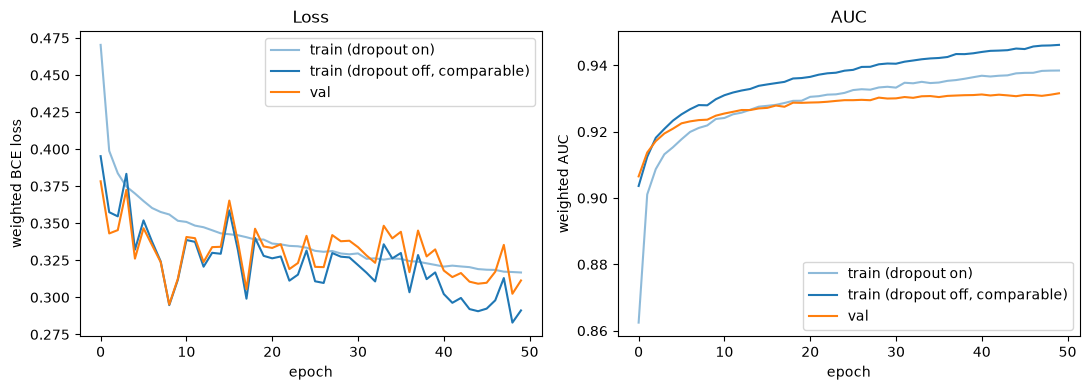

Final weighted AUC: train=0.9462 val=0.9316


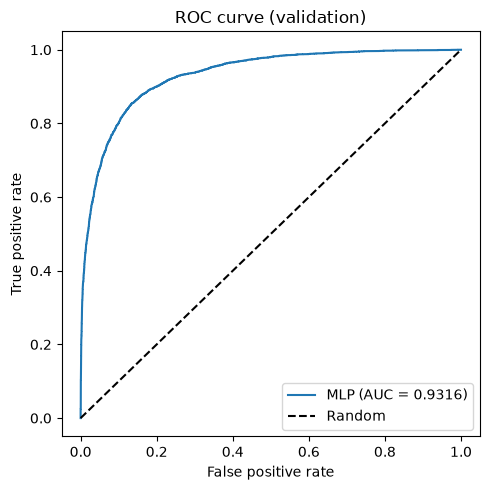

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

# NOTE: the faint "train (dropout on)" curve is measured mid-training with
# dropout active and class-balanced fit-weights - it's what the optimizer
# actually sees, not a fair comparison to val. The solid "train (dropout
# off, comparable)" curve (same eval mode + |w_phys| weights as val) is the
# one to read an honest train/val gap off of.

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(fd0_run2["X_train_t"])).cpu().numpy()
    val_probs = torch.sigmoid(model(fd0_run2["X_val_t"])).cpu().numpy()

y_train, y_val = fd0_run2["train_df"]["label"].to_numpy(), fd0_run2["val_df"]["label"].to_numpy()
w_train_abs = fd0_run2["train_df"]["w_phys"].to_numpy()  # already non-negative post-drop
w_val_abs = np.abs(fd0_run2["val_df"]["w_phys"].to_numpy())  # plain |w_phys| - AUC convention for val/test everywhere

auc_train = roc_auc_score(y_train, train_probs, sample_weight=w_train_abs)
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_abs)

print(f"Final weighted AUC (fold-0 preview): train={auc_train:.4f} val={auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_abs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"MLP (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation)

XGBoost has a built-in gain-based importance, but a neural net doesn't - the
model-agnostic equivalent is **permutation importance**: shuffle one
feature's column across events (destroying its relationship with the
label) and measure how much the weighted validation AUC drops. Repeated a
few times per feature and averaged for stability. Computed on the
validation set so it isn't inflated by the model simply memorizing train.

In [11]:
def permutation_importance(model, X, y, w, features, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors (e.g. X_val_t/y_val_t/w_val_t) with columns in the
    same order as `features`. Returns a pandas Series (feature -> mean AUC
    drop), sorted descending - a bigger drop means the model relies on that
    feature more.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    
    for i, feat in enumerate(features):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=features, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance (same
    convention as the XGBoost master pipeline's plot_importance_bar). If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

Baseline weighted AUC: 0.9316
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportanceFull_MLP.png


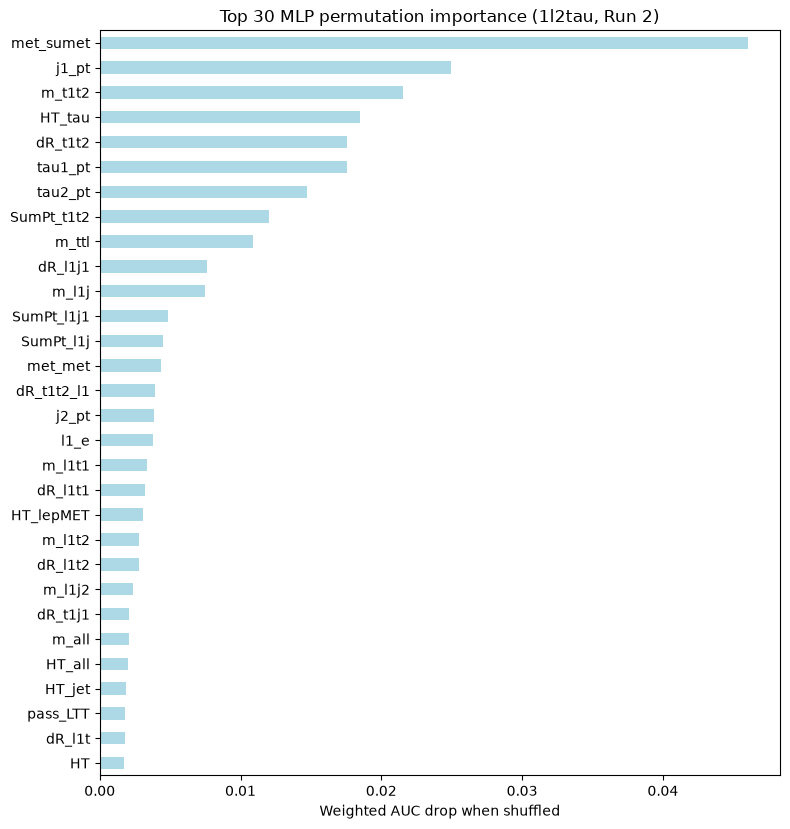

met_sumet     0.046016
j1_pt         0.024942
m_t1t2        0.021554
HT_tau        0.018458
dR_t1t2       0.017568
tau1_pt       0.017555
tau2_pt       0.014692
SumPt_t1t2    0.012033
m_ttl         0.010856
dR_l1j1       0.007647
m_l1j         0.007475
SumPt_l1j1    0.004827
SumPt_l1j     0.004460
met_met       0.004341
dR_t1t2_l1    0.003909
Name: auc_drop, dtype: float64

In [ ]:
importance = permutation_importance(model, fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
                                     features, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="Top 30 MLP permutation importance (1l2tau, Run 2, fold-0 preview)",
                     save_path=PLOTS_DIR_R2 / "Run2ImportanceFull_MLP.png")
importance.head(15)


## Correlation Pruning & Retraining

Mirrors the XGBoost master pipeline's correlation-pruning stage: rank
features by importance (permutation importance here, gain there), look at
Pearson correlation among the top candidates separately for signal and
background, then walk the ranked list keeping a feature only if it isn't
too correlated (`|corr| > 0.75`) with a more important feature already kept.
The MLP is then retrained from scratch on the decorrelated feature set, and
again restricted to just the top 15 features, to see how much (if any)
performance is lost by cutting redundant/less useful inputs.

In [ ]:
TOP_N_IMPORTANCE = 30   # candidate pool size, before correlation pruning
CORR_THRESH = 0.75      # |corr| above this -> considered redundant
N_KEEP = 20             # decorrelated features to keep in the main pruned model


def top_pairs(corr, thr=0.70):

    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """
    Pearson correlation of `feats`, computed separately for each value of
    `group_col` (label 0/1 = background/signal here) - correlations
    genuinely differ between groups, so pruning must look at both, not just
    the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """

    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


def subset_feature_tensors_fold(fd, feature_subset, all_features):

    """
    Slice a fold's already-scaled train/val/test GPU tensors (from
    `prepare_fold_tensors`) down to `feature_subset` (columns picked by
    name, matching `all_features`'s order) - same convention as this
    notebook's original (pre-k-fold) subset_feature_tensors: only the
    scaled PHYSICS-feature columns are sliced, the __isnan flag columns (if
    any, appended after column len(all_features)) are intentionally
    dropped, matching the original correlation-pruning behavior. TEST is
    only ever subset here for the final production run (`run_kfold_nn`) -
    never for training or model selection at the fold-0-preview stage.
    """

    idx = [all_features.index(f) for f in feature_subset]
    idx_t = torch.as_tensor(idx, device=DEVICE)
    return fd["X_train_t"][:, idx_t], fd["X_val_t"][:, idx_t], fd["X_test_t"][:, idx_t]


Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2CorrelationTop30_MLP.png


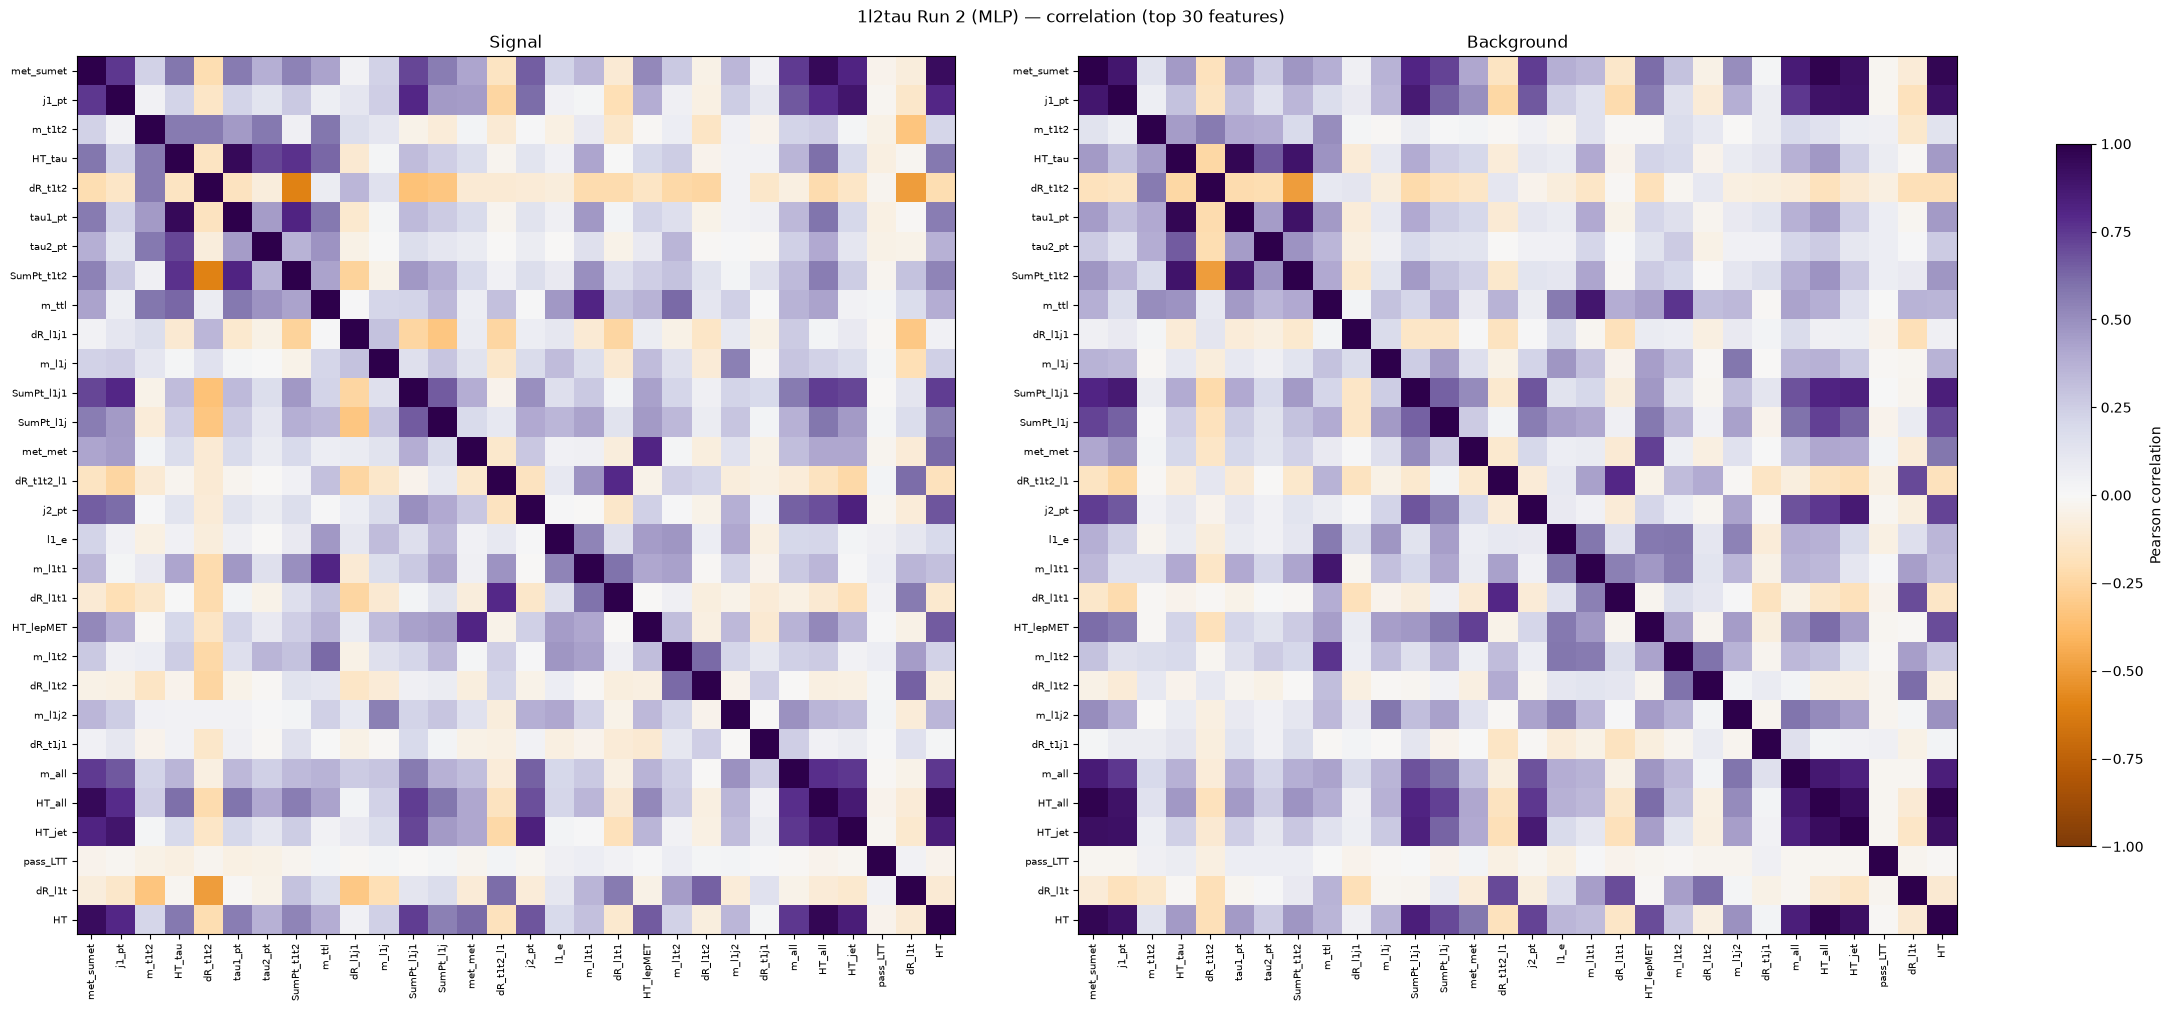

Pairs with |corr| > 0.50 (signal):
HT_all      HT            0.968501
met_sumet   HT_all        0.951155
HT_tau      tau1_pt       0.945766
met_sumet   HT            0.930010
j1_pt       HT_jet        0.887329
HT_all      HT_jet        0.862040
HT_jet      HT            0.850019
j2_pt       HT_jet        0.830150
met_sumet   HT_jet        0.815413
tau1_pt     SumPt_t1t2    0.812904
met_met     HT_lepMET     0.810867
m_ttl       m_l1t1        0.805546
j1_pt       SumPt_l1j1    0.802792
            HT            0.797357
dR_t1t2_l1  dR_l1t1       0.794670
j1_pt       HT_all        0.787930
m_all       HT_all        0.775714
HT_tau      SumPt_t1t2    0.768862
m_all       HT_jet        0.755706
met_sumet   j1_pt         0.755326
m_all       HT            0.750750
met_sumet   m_all         0.746627
SumPt_l1j1  HT            0.741407
            HT_all        0.740921
            HT_jet        0.716588
HT_tau      tau2_pt       0.716004
met_sumet   SumPt_l1j1    0.711588

Pairs with |corr| >

In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
# Uses fold-0's TRAIN partition only (not the full track dataset), matching
# the XGBoost master pipelines' fold-0-preview convention.

top_feats = importance.index[:TOP_N_IMPORTANCE].tolist()
corrs = grouped_correlations(fd0_run2["train_df"], top_feats, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs[1], corrs[0]], ["Signal", "Background"], top_feats,
    suptitle=f"1l2tau Run 2 (MLP) — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationTop30_MLP.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs[0]).to_string())


In [15]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.

corr_max = corrs[1].abs().combine(corrs[0].abs(), np.maximum)
PRUNED_FEATURES, dropped_features = prune_correlated(top_feats, corr_max, CORR_THRESH, N_KEEP)

Kept 18 decorrelated features (most -> least important):
   1. met_sumet
   2. m_t1t2
   3. HT_tau
   4. dR_t1t2
   5. tau2_pt
   6. m_ttl
   7. dR_l1j1
   8. m_l1j
   9. SumPt_l1j
  10. met_met
  11. dR_t1t2_l1
  12. j2_pt
  13. l1_e
  14. dR_l1t2
  15. m_l1j2
  16. dR_t1j1
  17. pass_LTT
  18. dR_l1t

Dropped 12 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.882)
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.895)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.805)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.877)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.811)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.760)
  m_all           -> redundant with met_sumet       (|corr| = 0.85

Full model      (64 features): train_auc_eval = 0.9462 | val_auc = 0.9316
Pruned model     (18 features): train_auc_eval = 0.9358 | val_auc = 0.9313
Baseline weighted AUC: 0.9313
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportancePruned_MLP.png


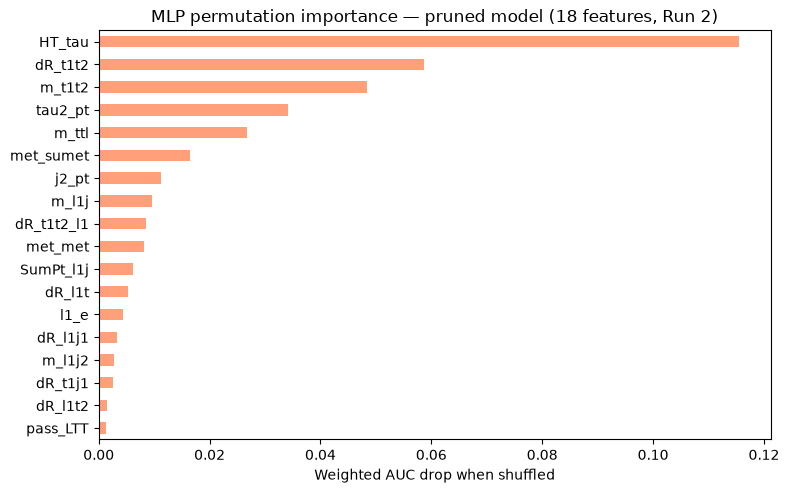

Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2CorrelationPruned_MLP.png


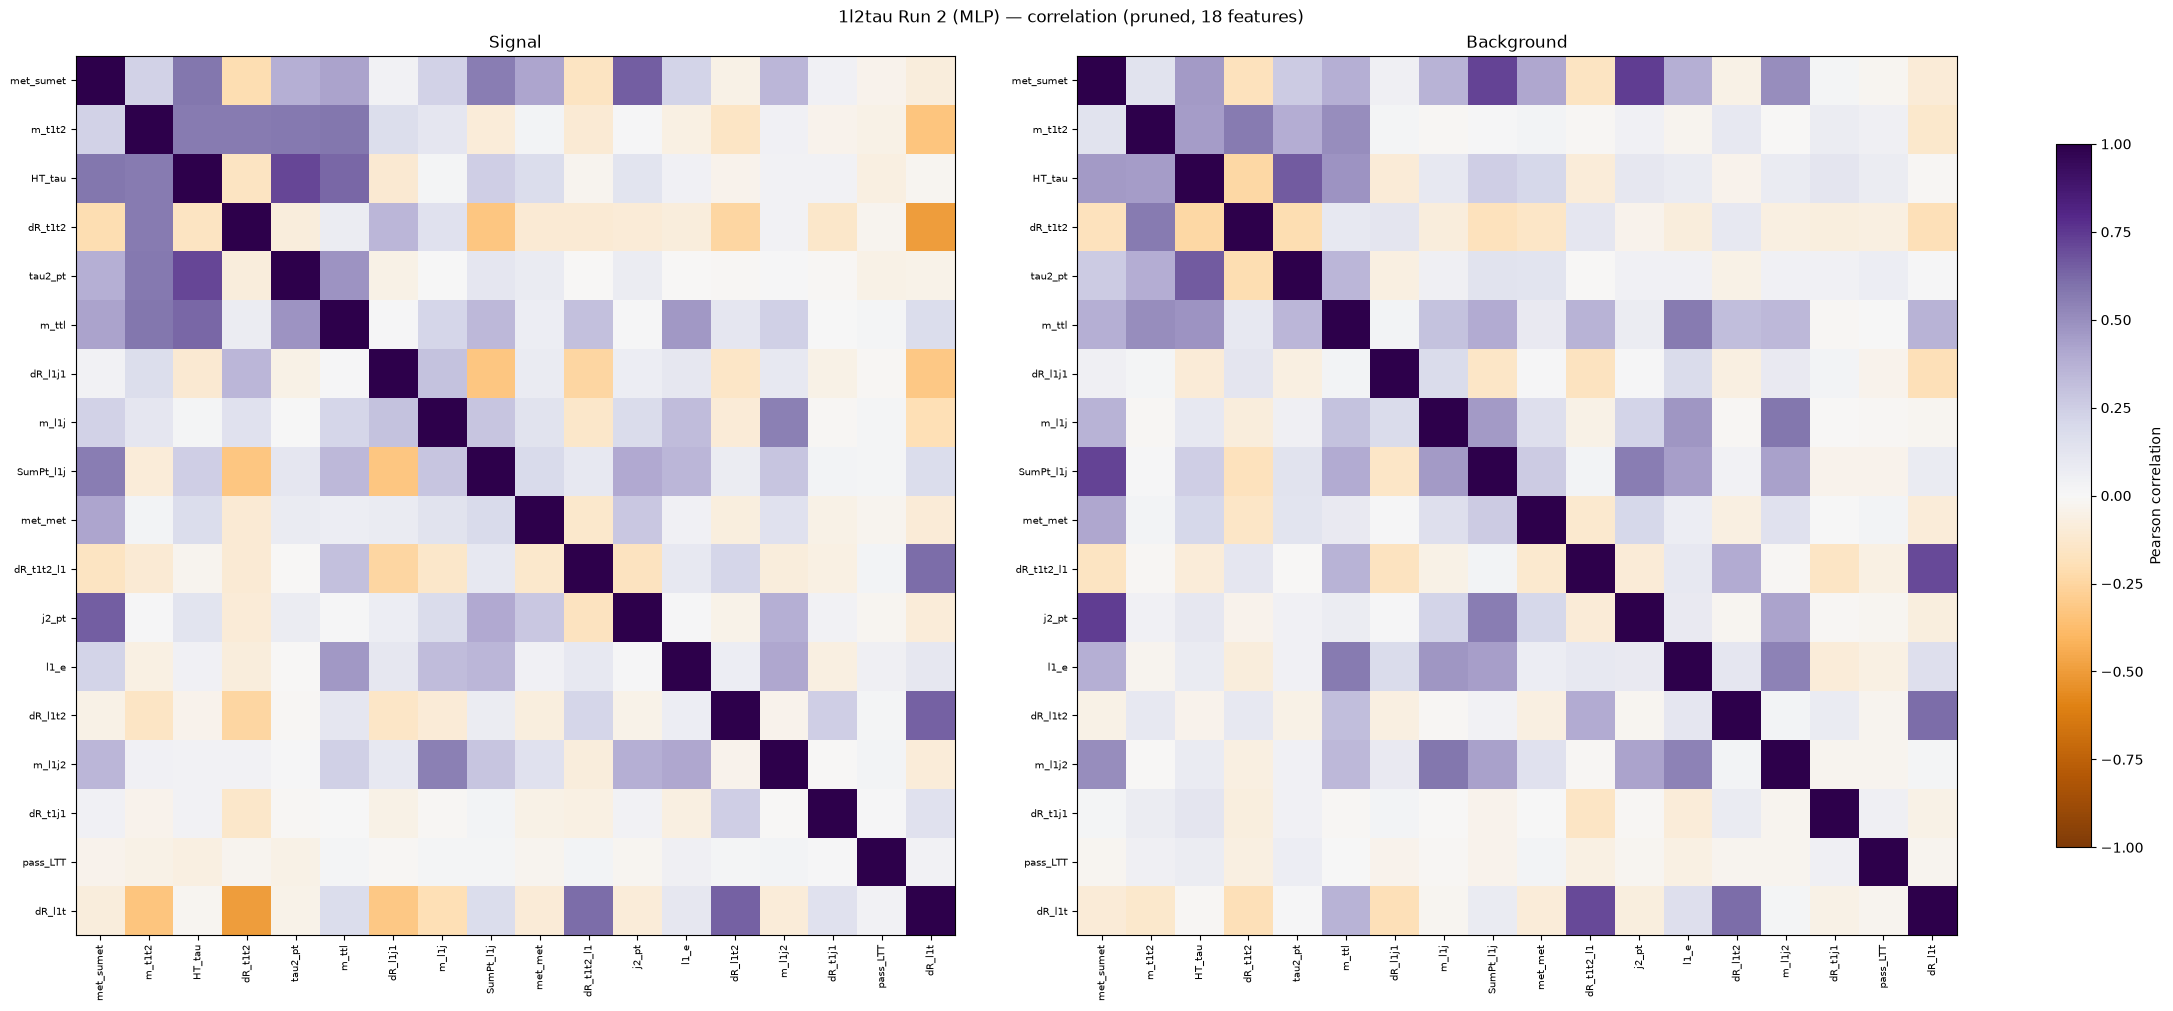

In [ ]:
# ---- Retrain on the pruned feature set (fold-0 preview) --------------------
X_train_pruned_t, X_val_pruned_t, X_test_pruned_t = subset_feature_tensors_fold(fd0_run2, PRUNED_FEATURES, features)

model_pruned, history_pruned, val_auc_pruned, train_auc_pruned, train_auc_eval_pruned = train_model(
    X_train_pruned_t, fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    X_val_pruned_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes, dropout=best_params_run2["dropout"], lr=best_params_run2["lr"],
    weight_decay=best_params_run2["weight_decay"], batch_size=best_params_run2["batch_size"],
    patience=best_params_run2["patience"], w_train_eval_data=fd0_run2["w_train_abs_t"], verbose=False,
)

print(f"Full model      ({len(features):2d} features): train_auc_eval = {best_train_auc_eval:.4f} | val_auc = {best_val_auc:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES):2d} features): train_auc_eval = {train_auc_eval_pruned:.4f} | val_auc = {val_auc_pruned:.4f}")

importance_pruned = permutation_importance(model_pruned, X_val_pruned_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
                                            PRUNED_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_pruned, top_n=len(PRUNED_FEATURES),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES)} features, Run 2)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R2 / "Run2ImportancePruned_MLP.png",
)

pruned_corrs = grouped_correlations(fd0_run2["train_df"], PRUNED_FEATURES, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs[1], pruned_corrs[0]], ["Signal", "Background"], PRUNED_FEATURES,
    suptitle=f"1l2tau Run 2 (MLP) — correlation (pruned, {len(PRUNED_FEATURES)} features, fold-0 preview)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationPruned_MLP.png",
)


## Top-15 Features Only

Same correlation-pruning walk over the same top-30 candidate pool, but
stopped once 15 decorrelated features are kept, to see how much (if any)
weighted validation AUC is lost by cutting down to a much smaller,
easier-to-interpret feature set.

Kept 15 decorrelated features (most -> least important):
   1. met_sumet
   2. m_t1t2
   3. HT_tau
   4. dR_t1t2
   5. tau2_pt
   6. m_ttl
   7. dR_l1j1
   8. m_l1j
   9. SumPt_l1j
  10. met_met
  11. dR_t1t2_l1
  12. j2_pt
  13. l1_e
  14. dR_l1t2
  15. m_l1j2

Dropped 8 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.882)
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.967)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.895)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.805)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.877)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.811)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.760)


Baseline weighted AUC: 0.9298
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportanceTop15_MLP.png


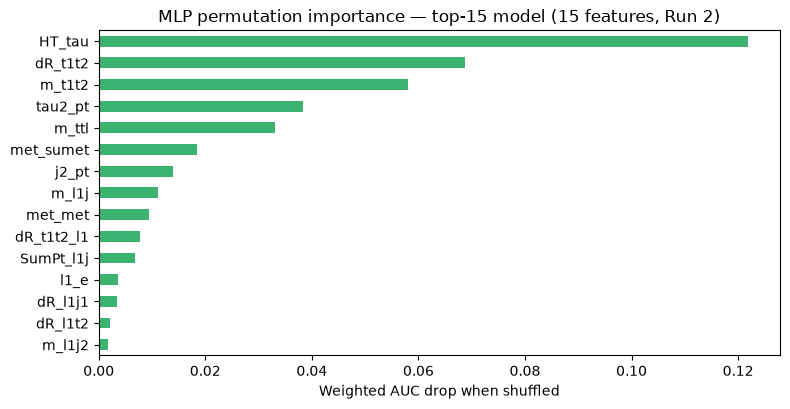


Weighted train(eval-mode)/validation AUC comparison:


,model,train_auc_eval,val_auc
0,Full (64 features),0.946191,0.931592
1,Pruned (18 features),0.935817,0.931251
2,Top-15 (15 features),0.934262,0.929808


In [ ]:
TOP15_FEATURES, dropped_top15 = prune_correlated(top_feats, corr_max, CORR_THRESH, n_keep=15)

X_train_top15_t, X_val_top15_t, X_test_top15_t = subset_feature_tensors_fold(fd0_run2, TOP15_FEATURES, features)

model_top15, history_top15, val_auc_top15, train_auc_top15, train_auc_eval_top15 = train_model(
    X_train_top15_t, fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    X_val_top15_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes, dropout=best_params_run2["dropout"], lr=best_params_run2["lr"],
    weight_decay=best_params_run2["weight_decay"], batch_size=best_params_run2["batch_size"],
    patience=best_params_run2["patience"], w_train_eval_data=fd0_run2["w_train_abs_t"], verbose=False,
)

importance_top15 = permutation_importance(model_top15, X_val_top15_t, fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
                                           TOP15_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_top15, top_n=len(TOP15_FEATURES),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES)} features, Run 2)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_R2 / "Run2ImportanceTop15_MLP.png",
)

comparison = pd.DataFrame([
    {"model": f"Full ({len(features)} features)", "train_auc_eval": best_train_auc_eval, "val_auc": best_val_auc},
    {"model": f"Pruned ({len(PRUNED_FEATURES)} features)", "train_auc_eval": train_auc_eval_pruned, "val_auc": val_auc_pruned},
    {"model": f"Top-15 ({len(TOP15_FEATURES)} features)", "train_auc_eval": train_auc_eval_top15, "val_auc": val_auc_top15},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (fold-0 preview):")
comparison


## Physics Figure of Merit & Final Summary (Validation Set)

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This section reports a max-Asimov-significance
scan for the **last pruned model (top-15 features)** - the most
decorrelated/interpretable feature set from the pruning walk above - plus a
low-FPR ROC view and signal efficiency at fixed background-rejection
working points, all on the **validation** set (used for model/cut
selection). The genuinely blind number - the same model, same score cut,
scored on the untouched **test** partition - is reported once in the
"Held-Out Test Evaluation" section right after this one.


In [ ]:
# ---- Score the model with the best fold-0-preview val_auc (Full/Pruned/
# Top-15, per `comparison` above) - `significance_scan` is the canonical
# copy from the K-Fold helper library above, not redefined here.
FEATURE_SETS_R2 = {
    f"Full ({len(features)} features)": (model, features, fd0_run2["X_val_t"]),
    f"Pruned ({len(PRUNED_FEATURES)} features)": (model_pruned, PRUNED_FEATURES, X_val_pruned_t),
    f"Top-15 ({len(TOP15_FEATURES)} features)": (model_top15, TOP15_FEATURES, X_val_top15_t),
}
best_name = comparison.iloc[0]["model"]
final_model, FINAL_FEATURES_R2, X_val_final_t = FEATURE_SETS_R2[best_name]

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_final_t)).cpu().numpy()

y_val = fd0_run2["val_df"]["label"].to_numpy()
w_val_signed = fd0_run2["val_df"]["w_phys"].to_numpy()  # signed - expected yields

z_val, thr_val = significance_scan(y_val, val_scores, w_val_signed)
final_val_auc = comparison.loc[comparison["model"] == best_name, "val_auc"].iloc[0]
final_train_auc_eval = comparison.loc[comparison["model"] == best_name, "train_auc_eval"].iloc[0]

print(f"Final feature set (fold-0 preview): {best_name}")
print(f"Weighted val AUC = {final_val_auc:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9298
Max Asimov Z (val) = 0.027 at score cut = 0.9825


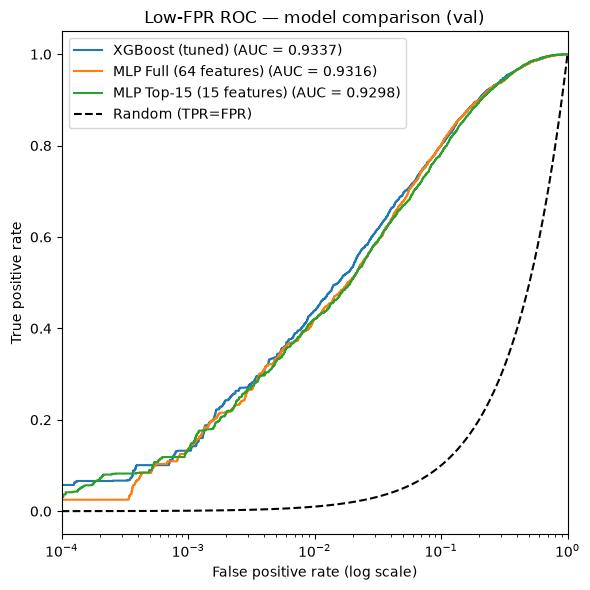

--- FPR = 1e-03 (~60 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.1323  (132x random lift)
  MLP Full (64 features)           TPR = 0.1356  (136x random lift)
  MLP Top-15 (15 features)         TPR = 0.1323  (132x random lift)
--- FPR = 1e-02 (~602 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4392  (44x random lift)
  MLP Full (64 features)           TPR = 0.4203  (42x random lift)
  MLP Top-15 (15 features)         TPR = 0.4204  (42x random lift)


In [ ]:
# ---- Load a tuned XGBoost fold-0 model (same 1l2tau Run 2 track, k-fold
# artifacts from Esteban/1L2Tau_Master_Pipeline.ipynb's save_track_artifacts)
# for an apples-to-apples overlay, scored on this notebook's fold-0 val
# partition (fd0_run2["val_df"]) - both notebooks use the SAME eventNumber
# fold assignment, so fold 0's val rows are identical event sets.

import xgboost as xgb

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(BASE_DIR / "model_run2_fold0.json")
with open(BASE_DIR / "features_run2.json") as f:
    xgb_features = json.load(f)

xgb_val_scores = xgb_model.predict_proba(fd0_run2["val_df"][xgb_features])[:, 1]


def roc_with_auc(y_true, scores, w):
    fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=w)
    auc = roc_auc_score(y_true, scores, sample_weight=w)
    return fpr, tpr, auc


# Model-vs-model overlay on the SAME val rows/|w_phys| weights - this is the
# plot that actually answers "which model holds more signal at fixed
# background rejection", not a single curve vs. a (wrong) diagonal.

# ROC curve for the FINAL model (best fold-0-preview feature set, `val_scores`
# from the significance-scan cell above), not necessarily the full model.
fpr_val, tpr_val, _ = roc_curve(y_val, val_scores, sample_weight=w_val_abs)

curves = {
    "XGBoost (tuned, fold 0)": roc_with_auc(y_val, xgb_val_scores, w_val_abs),
    f"MLP Full ({len(features)} features)": roc_with_auc(y_val, val_probs, w_val_abs),
    f"MLP {best_name}": (fpr_val, tpr_val, final_val_auc),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")


x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()

# Caveat: below ~1e-3 FPR the surviving background is down to O(100) MC
# events, so the leftmost decade - especially any uptick right at the 1e-4
# edge - is statistical wobble, not a real effect. 

n_bkg_val = int((y_val == 0).sum())

for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")


In [ ]:
# ---- Sanity checks --------------------------------------------------------

assert torch.isfinite(fd0_run2["X_train_t"]).all() and torch.isfinite(fd0_run2["X_val_t"]).all(), \
    "NaN/inf reached the model input"

# Determinism check (Task 1's acceptance criterion): re-seeding immediately
# before each of two short training runs should give an EXACT match, proving
# set_seed()/use_deterministic_algorithms(True) actually pin every source of
# randomness (weight init, dropout masks, batch shuffling). Uses a cheap
# config (small model, 5 epochs) purely to keep this check fast - it is not
# meant to reflect final model quality.

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(
    fd0_run2["X_train_t"], fd0_run2["y_train_t"], fd0_run2["w_train_fit_t"],
    fd0_run2["X_val_t"], fd0_run2["y_val_t"], fd0_run2["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Fold-0-preview summary (feature-selection stage only - NOT the final
# k-fold production model, see the K-Fold Production Run section below) ----
summary = pd.DataFrame([{
    "model": best_name,
    "train_auc_eval": final_train_auc_eval,
    "val_auc": final_val_auc,
    "max_asimov_Z (val)": z_val,
}])

print("\nFold-0-preview summary (MLP, 1l2tau Run 2):")
print(summary.to_string(index=False))
summary


Determinism check passed: two re-seeded runs give identical val_auc = 0.911823

Final summary (MLP, 1l2tau Run 2):
               model  train_auc_eval  val_auc  max_asimov_Z (val)
Top-15 (15 features)        0.934262 0.929808            0.027207


,model,train_auc_eval,val_auc,max_asimov_Z (val)
0,Top-15 (15 features),0.934262,0.929808,0.027207


## K-Fold Production Run & Artifacts (Run 2)

Everything above (Optuna search, correlation pruning, permutation
importance) used only fold 0 as a representative preview - purely to freeze
hyperparameters and pick a final feature set. This is where the actual
5-fold OOF production run happens: `run_kfold_nn` trains one model per fold
(frozen tuned hyperparameters, `best_params_run2`, on `FINAL_FEATURES_R2`,
the feature set chosen by the fold-0 preview above) and scores every event
with a model that never trained on it. Replaces the old single
train/val/test split's "Held-Out Test Evaluation" cell - there is no single
held-out test set anymore, only the pooled OOF metrics below.


In [ ]:
# ---- K-FOLD PRODUCTION RUN (Run 2) -----------------------------------------
flag_cols_final_run2 = [f for f in flag_cols_run2 if f in FINAL_FEATURES_R2]

oof_df_run2, models_run2, scalers_run2, medians_run2 = run_kfold_nn(
    data_run2, FINAL_FEATURES_R2, flag_cols_final_run2, best_params_run2, target_yields_run2,
    cell_cols=(), n_folds=N_FOLDS, label="Run2",
)

oof_auc_run2 = plot_oof_roc(oof_df_run2, title="1l2tau Run 2 (MLP) - OOF ROC")

save_track_artifacts_nn(
    models_run2, scalers_run2, medians_run2, FINAL_FEATURES_R2, flag_cols_final_run2,
    best_params_run2, oof_df_run2, BASE_DIR_RUN2, "run2",
)


Final model: Top-15 (15 features)
Weighted AUC: val(holdout)=0.9298  test(held-out, scored once)=0.9339
Asimov Z at val-selected cut (0.9825, frozen): val=0.027  test=0.027


## Run 3 (Separate Downstream Section)

Run 2 remains the first complete pass above. To start a separate Run 3 pass,
run the next cell to switch the active dataset, then continue with your
Run 3 downstream cells.

In [22]:
# Activate Run 3 as the downstream dataset. Everything below uses `_run3`
# suffixed variable names so the Run 2 results above remain untouched.

candidate_features, data, features = candidate_features_run3, data_run3, features_run3

BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

print(f"Switched downstream dataset to: {ACTIVE_RUN}")
print(f"Events={len(data)} | features={len(features)}")

Switched downstream dataset to: Run 3
Events=1324892 | features=64


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section above, run separately on `data_run3`/
`features_run3`.

In [23]:
NEG1_SENTINEL_FEATURES_run3 = set()

neg1_rows_run3 = []
for f in features_run3:
    vals = data_run3[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_run3.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_run3 = pd.DataFrame(neg1_rows_run3).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_run3)} / {len(features_run3)} features have at least one row exactly equal to -1:")
print(neg1_df_run3.to_string(index=False))

# Apply the (currently empty) mask before the train/val split, same convention as Run 2.
for f in NEG1_SENTINEL_FEATURES_run3:
    data_run3[f] = data_run3[f].mask(data_run3[f] == -1)
if NEG1_SENTINEL_FEATURES_run3:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_run3)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474795                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing — Run 3

Same 80/10/10 `make_3way_split`, median imputation (fit on train only),
standard scaling, and `__isnan` missingness flags as the Run 2 section,
applied to `data_run3`. Kept in separate `_run3` variables so the Run 2
train/val/test tensors above are unaffected. TEST is held out until the
"Held-Out Test Evaluation" cell at the end of this track.


In [ ]:
# ---- Weight-balance diagnostics (Run 3, representative fold 0) ------------
PLOTS_DIR_R3 = BASE_DIR_RUN3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)

target_yields_run3 = compute_process_yield_targets(data_run3)
flag_cols_run3 = compute_flag_cols(data_run3, features_run3)
N_FEATURES_MODEL = len(features_run3) + len(flag_cols_run3)

fd0_run3 = prepare_fold_tensors(data_run3, features_run3, flag_cols_run3, target_yields_run3,
                                 cell_cols=(), n_folds=N_FOLDS, k=0)

w_before_run3 = fd0_run3["train_df"]["w_phys"].to_numpy()
w_after_run3 = fd0_run3["w_train_fit"]
y_preview_run3 = fd0_run3["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_run3, w_before_run3, w_after_run3,
    title="Run 3 (MLP) - make_fit_weights balancing (fold 0 train)",
    save_path=PLOTS_DIR_R3 / "Run3WeightBalance_MLP.png",
)

print(f"{len(flag_cols_run3)} features had missing values in train (globally) -> added "
      f"{len(flag_cols_run3)} __isnan flag columns (final model input width = {N_FEATURES_MODEL} = "
      f"{len(features_run3)} features + {len(flag_cols_run3)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by label - fold 0:")
print(n_eff_table(fd0_run3["train_df"], ["label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by label:")
print(n_eff_table(fd0_run3["test_df"], ["label"]))
print(f"\nDropped {fd0_run3['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


Train: 1059912 events | signal = 164040 | background = 895872
Val:   132490 events | signal = 20505 | background = 111985
Test:  132490 events | signal = 20505 | background = 111985  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 64 = 64 features + 0 flags)
Dropped 111243/1059912 negative-w_phys training events (10.5%) - kept, not abs'd
Signal weight scale factor (train, post-filter): 11050.4


## PyTorch Dataset & Model — Run 3

In [ ]:
model_run3 = build_model(n_features=fd0_run3["n_features_model"])

print(model_run3)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Training Loop — Run 3

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_run3` tensors passed in so the Run 2 model/
history are untouched.

In [ ]:
# ---- Fold-0 preview baseline (default hyperparameters) - used only to rank
# features for the correlation-pruning stage below.
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=(128, 64), w_train_eval_data=fd0_run3["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")


Epoch   1 | train_loss=0.4615 val_loss=0.6621 | train_auc=0.8683 train_auc_eval=0.9118 val_auc=0.8938
Epoch   2 | train_loss=0.3871 val_loss=0.5554 | train_auc=0.9075 train_auc_eval=0.9196 val_auc=0.8998
Epoch   3 | train_loss=0.3748 val_loss=0.4961 | train_auc=0.9134 train_auc_eval=0.9232 val_auc=0.9025
Epoch   4 | train_loss=0.3664 val_loss=0.4787 | train_auc=0.9172 train_auc_eval=0.9257 val_auc=0.9054
Epoch   5 | train_loss=0.3617 val_loss=0.4673 | train_auc=0.9194 train_auc_eval=0.9276 val_auc=0.9074
Epoch   6 | train_loss=0.3572 val_loss=0.4324 | train_auc=0.9214 train_auc_eval=0.9291 val_auc=0.9106
Epoch   7 | train_loss=0.3568 val_loss=0.3885 | train_auc=0.9215 train_auc_eval=0.9299 val_auc=0.9161
Epoch   8 | train_loss=0.3510 val_loss=0.3833 | train_auc=0.9242 train_auc_eval=0.9312 val_auc=0.9218
Epoch   9 | train_loss=0.3478 val_loss=0.3796 | train_auc=0.9256 train_auc_eval=0.9325 val_auc=0.9234
Epoch  10 | train_loss=0.3469 val_loss=0.3467 | train_auc=0.9260 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Run 3

In [ ]:
study_run3 = run_optuna_search_nn(data_run3, features_run3, flag_cols_run3, target_yields_run3,
                                   study_name="mlp_opt_run3")
best_params_run3 = params_from_study_nn(study_run3)
best_hidden_sizes_run3 = best_params_run3["hidden_sizes"]
plot_optuna_diagnostics_nn(study_run3, title_suffix="(1l2tau, Run 3, MLP)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters -------
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=best_params_run3["hidden_sizes"], dropout=best_params_run3["dropout"],
    lr=best_params_run3["lr"], weight_decay=best_params_run3["weight_decay"],
    batch_size=best_params_run3["batch_size"], patience=best_params_run3["patience"],
    w_train_eval_data=fd0_run3["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc_run3:.4f} | hidden_sizes={best_hidden_sizes_run3}")


hidden_sizes=(64,)            -> train_auc=0.9310 val_auc=0.9379
hidden_sizes=(128, 64)        -> train_auc=0.9395 val_auc=0.9406
hidden_sizes=(256, 128)       -> train_auc=0.9442 val_auc=0.9407
hidden_sizes=(128, 64, 32)    -> train_auc=0.9390 val_auc=0.9402
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9387 val_auc=0.9404

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9407


## Evaluation — Run 3

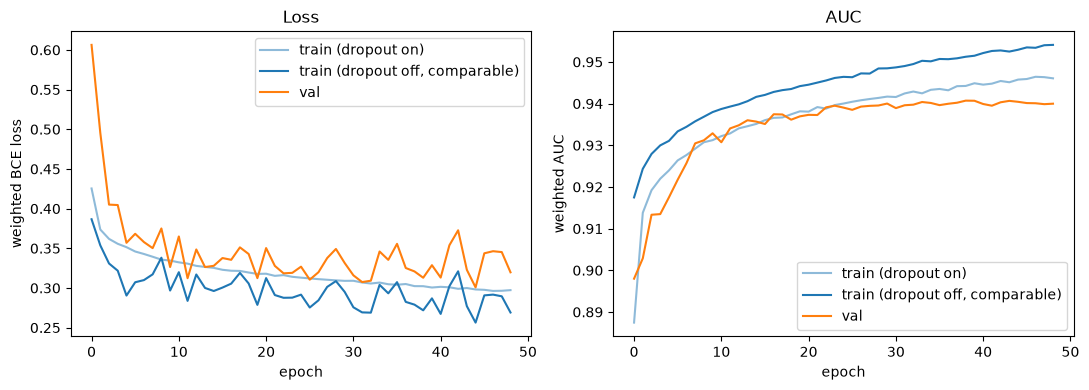

Final weighted AUC: train=0.9512 val=0.9407


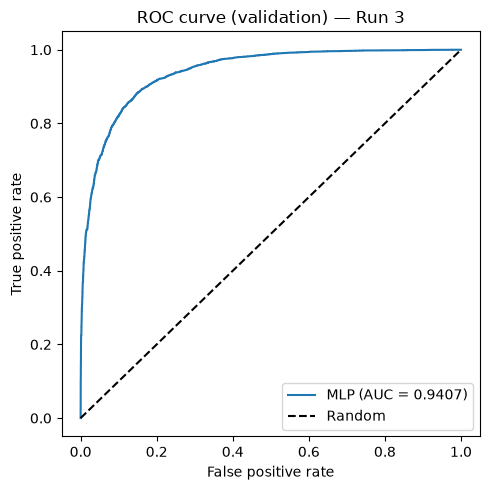

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_run3.eval()
with torch.no_grad():
    train_probs_run3 = torch.sigmoid(model_run3(fd0_run3["X_train_t"])).cpu().numpy()
    val_probs_run3 = torch.sigmoid(model_run3(fd0_run3["X_val_t"])).cpu().numpy()

y_train_run3, y_val_run3 = fd0_run3["train_df"]["label"].to_numpy(), fd0_run3["val_df"]["label"].to_numpy()
w_train_abs_run3 = fd0_run3["train_df"]["w_phys"].to_numpy()
w_val_abs_run3 = np.abs(fd0_run3["val_df"]["w_phys"].to_numpy())

auc_train_run3 = roc_auc_score(y_train_run3, train_probs_run3, sample_weight=w_train_abs_run3)
auc_val_run3 = roc_auc_score(y_val_run3, val_probs_run3, sample_weight=w_val_abs_run3)

print(f"Final weighted AUC (fold-0 preview): train={auc_train_run3:.4f} val={auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, val_probs_run3, sample_weight=w_val_abs_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"MLP (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview) — Run 3")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation) — Run 3

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9407
Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3ImportanceFull_MLP.png


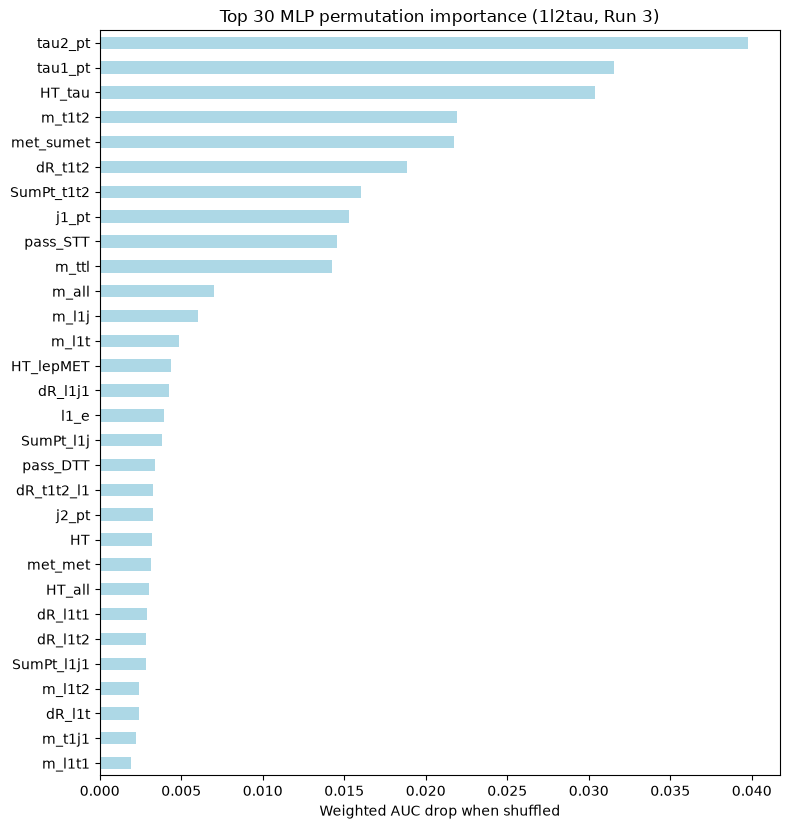

tau2_pt       0.039744
tau1_pt       0.031533
HT_tau        0.030374
m_t1t2        0.021914
met_sumet     0.021717
dR_t1t2       0.018829
SumPt_t1t2    0.016007
j1_pt         0.015283
pass_STT      0.014571
m_ttl         0.014279
m_all         0.006994
m_l1j         0.006043
m_l1t         0.004851
HT_lepMET     0.004377
dR_l1j1       0.004270
Name: auc_drop, dtype: float64

In [ ]:
importance_run3 = permutation_importance(model_run3, fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
                                          features_run3, n_repeats=5)
plot_importance_bar(importance_run3, top_n=30, title="Top 30 MLP permutation importance (1l2tau, Run 3, fold-0 preview)",
                     save_path=PLOTS_DIR_R3 / "Run3ImportanceFull_MLP.png")
importance_run3.head(15)


## Correlation Pruning & Retraining — Run 3

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on Run 3 inputs).

Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3CorrelationTop30_MLP.png


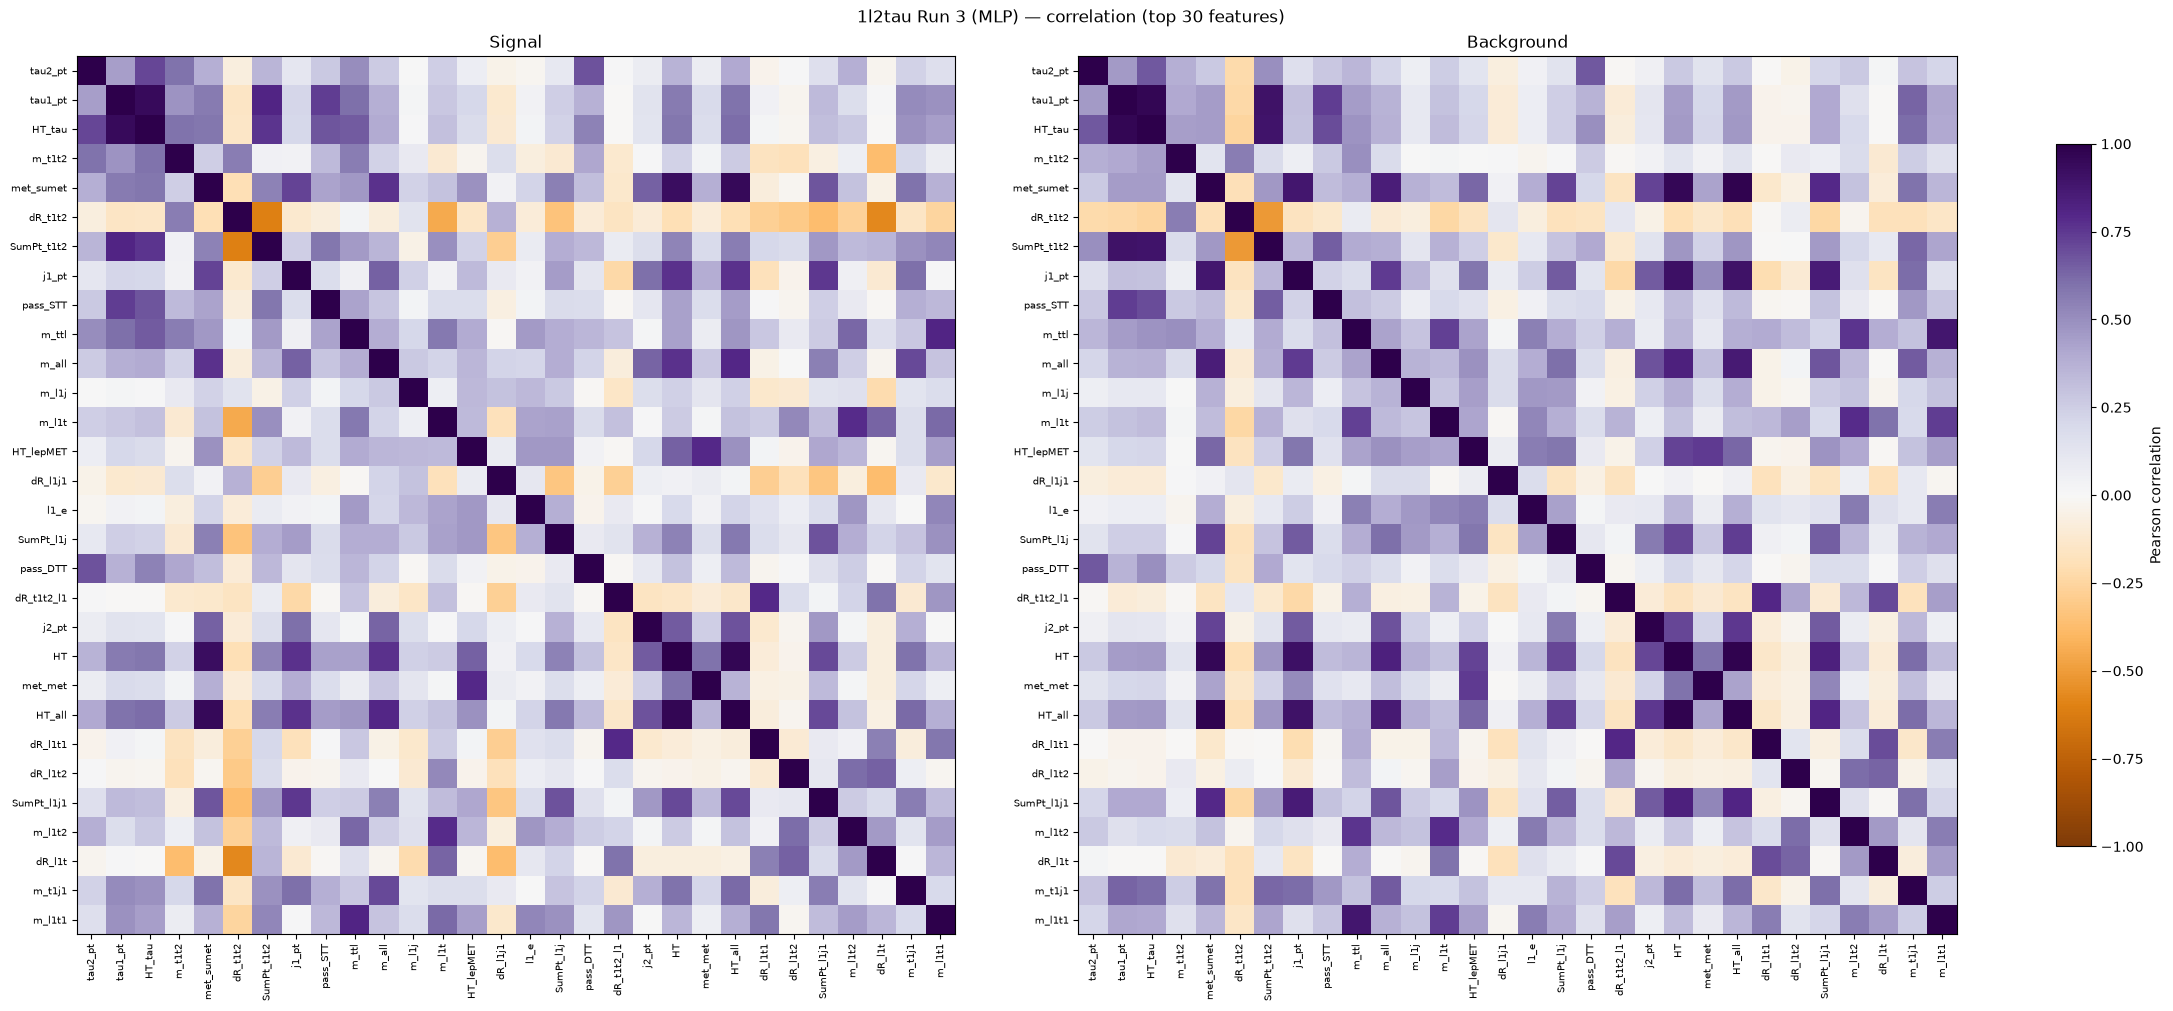

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.965227
met_sumet   HT_all        0.948426
tau1_pt     HT_tau        0.944209
met_sumet   HT            0.924214
m_ttl       m_l1t1        0.809769
tau1_pt     SumPt_t1t2    0.809316
m_all       HT_all        0.803421
dR_t1t2_l1  dR_l1t1       0.794290
HT_lepMET   met_met       0.792861
m_l1t       m_l1t2        0.788209
m_all       HT            0.770698
j1_pt       HT            0.770172
met_sumet   m_all         0.768420
j1_pt       HT_all        0.767195
HT_tau      SumPt_t1t2    0.763878
j1_pt       SumPt_l1j1    0.752508
tau1_pt     pass_STT      0.738444
met_sumet   j1_pt         0.725144
tau2_pt     HT_tau        0.711260
m_all       m_t1j1        0.706645
HT_all      SumPt_l1j1    0.706386
HT          SumPt_l1j1    0.703519

Pairs with |corr| > 0.50 (background):
met_sumet   HT_all        0.979360
HT          HT_all        0.978909
tau1_pt     HT_tau        0.967156
met_sumet   HT            0.960698
j1_pt       HT 

In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_run3 = importance_run3.index[:TOP_N_IMPORTANCE].tolist()
corrs_run3 = grouped_correlations(fd0_run3["train_df"], top_feats_run3, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_run3[1], corrs_run3[0]], ["Signal", "Background"], top_feats_run3,
    suptitle=f"1l2tau Run 3 (MLP) — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationTop30_MLP.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_run3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_run3[0]).to_string())


In [31]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------

corr_max_run3 = corrs_run3[1].abs().combine(corrs_run3[0].abs(), np.maximum)
PRUNED_FEATURES_run3, dropped_features_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, N_KEEP)

Kept 19 decorrelated features (most -> least important):
   1. tau2_pt
   2. tau1_pt
   3. m_t1t2
   4. met_sumet
   5. dR_t1t2
   6. pass_STT
   7. m_ttl
   8. m_l1j
   9. m_l1t
  10. HT_lepMET
  11. dR_l1j1
  12. l1_e
  13. SumPt_l1j
  14. pass_DTT
  15. dR_t1t2_l1
  16. j2_pt
  17. dR_l1t2
  18. dR_l1t
  19. m_t1j1

Dropped 11 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.879)
  m_all           -> redundant with met_sumet       (|corr| = 0.851)
  HT              -> redundant with met_sumet       (|corr| = 0.961)
  met_met         -> redundant with HT_lepMET       (|corr| = 0.793)
  HT_all          -> redundant with met_sumet       (|corr| = 0.979)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  SumPt_l1j1      -> redundant with met_sumet     

Full model      (64 features): train_auc_eval = 0.9512 | val_auc = 0.9407
Pruned model     (19 features): train_auc_eval = 0.9417 | val_auc = 0.9404
Baseline weighted AUC: 0.9404
Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3ImportancePruned_MLP.png


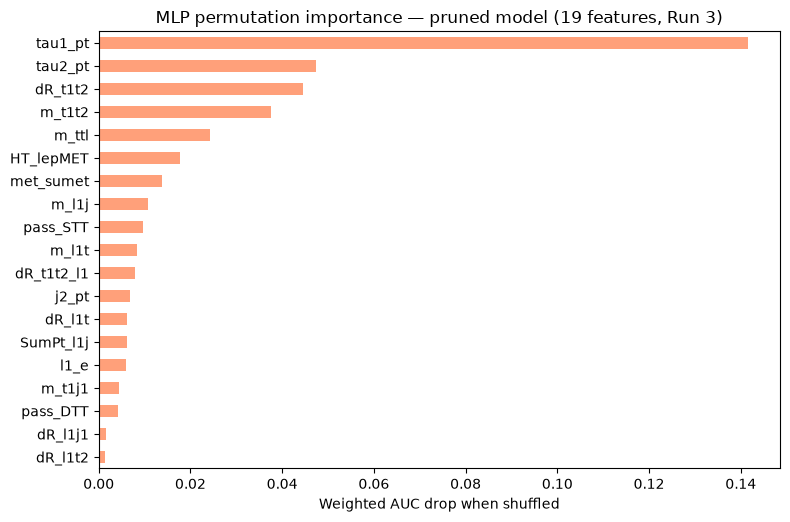

Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3CorrelationPruned_MLP.png


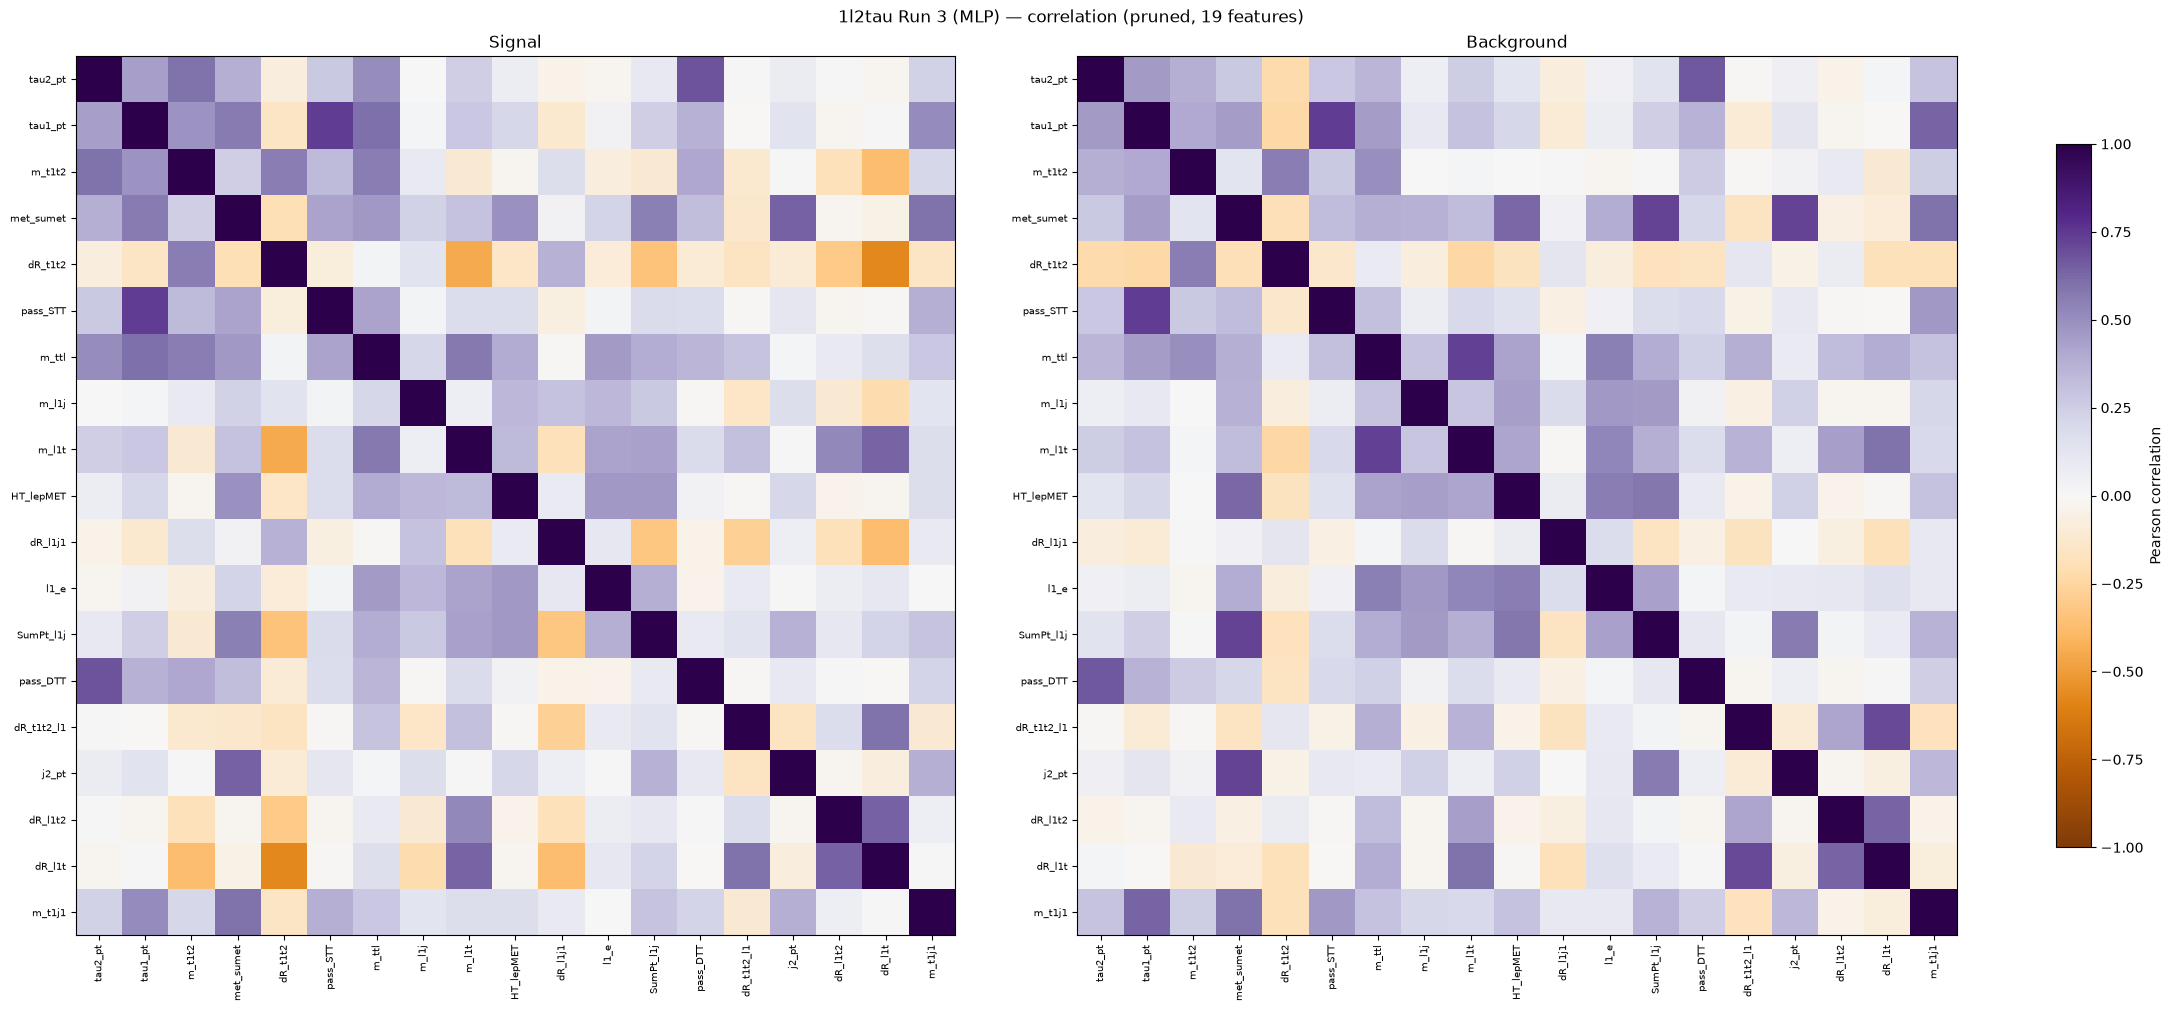

In [ ]:
# ---- Retrain on the pruned feature set (fold-0 preview) --------------------
X_train_pruned_t_run3, X_val_pruned_t_run3, X_test_pruned_t_run3 = subset_feature_tensors_fold(fd0_run3, PRUNED_FEATURES_run3, features_run3)

model_pruned_run3, history_pruned_run3, val_auc_pruned_run3, train_auc_pruned_run3, train_auc_eval_pruned_run3 = train_model(
    X_train_pruned_t_run3, fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    X_val_pruned_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_run3, dropout=best_params_run3["dropout"], lr=best_params_run3["lr"],
    weight_decay=best_params_run3["weight_decay"], batch_size=best_params_run3["batch_size"],
    patience=best_params_run3["patience"], w_train_eval_data=fd0_run3["w_train_abs_t"], verbose=False,
)

print(f"Full model      ({len(features_run3):2d} features): train_auc_eval = {best_train_auc_eval_run3:.4f} | val_auc = {best_val_auc_run3:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_run3):2d} features): train_auc_eval = {train_auc_eval_pruned_run3:.4f} | val_auc = {val_auc_pruned_run3:.4f}")

importance_pruned_run3 = permutation_importance(model_pruned_run3, X_val_pruned_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
                                                 PRUNED_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_pruned_run3, top_n=len(PRUNED_FEATURES_run3),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES_run3)} features, Run 3)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R3 / "Run3ImportancePruned_MLP.png",
)

pruned_corrs_run3 = grouped_correlations(fd0_run3["train_df"], PRUNED_FEATURES_run3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_run3[1], pruned_corrs_run3[0]], ["Signal", "Background"], PRUNED_FEATURES_run3,
    suptitle=f"1l2tau Run 3 (MLP) — correlation (pruned, {len(PRUNED_FEATURES_run3)} features, fold-0 preview)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationPruned_MLP.png",
)


## Top-15 Features Only — Run 3

Kept 15 decorrelated features (most -> least important):
   1. tau2_pt
   2. tau1_pt
   3. m_t1t2
   4. met_sumet
   5. dR_t1t2
   6. pass_STT
   7. m_ttl
   8. m_l1j
   9. m_l1t
  10. HT_lepMET
  11. dR_l1j1
  12. l1_e
  13. SumPt_l1j
  14. pass_DTT
  15. dR_t1t2_l1

Dropped 4 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.879)
  m_all           -> redundant with met_sumet       (|corr| = 0.851)


Baseline weighted AUC: 0.9388
Saved plot -> PPSSP_2026/1l2tau/run3/plots/Run3ImportanceTop15_MLP.png


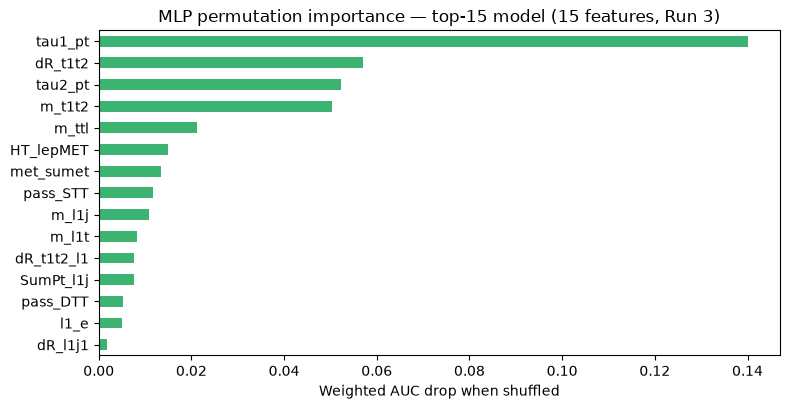


Weighted train(eval-mode)/validation AUC comparison (Run 3):


,model,train_auc_eval,val_auc
0,Full (64 features),0.951244,0.940713
1,Pruned (19 features),0.941740,0.940366
2,Top-15 (15 features),0.939714,0.938795


In [ ]:
TOP15_FEATURES_run3, dropped_top15_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, n_keep=15)

X_train_top15_t_run3, X_val_top15_t_run3, X_test_top15_t_run3 = subset_feature_tensors_fold(fd0_run3, TOP15_FEATURES_run3, features_run3)

model_top15_run3, history_top15_run3, val_auc_top15_run3, train_auc_top15_run3, train_auc_eval_top15_run3 = train_model(
    X_train_top15_t_run3, fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    X_val_top15_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_run3, dropout=best_params_run3["dropout"], lr=best_params_run3["lr"],
    weight_decay=best_params_run3["weight_decay"], batch_size=best_params_run3["batch_size"],
    patience=best_params_run3["patience"], w_train_eval_data=fd0_run3["w_train_abs_t"], verbose=False,
)

importance_top15_run3 = permutation_importance(model_top15_run3, X_val_top15_t_run3, fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
                                                TOP15_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_top15_run3, top_n=len(TOP15_FEATURES_run3),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES_run3)} features, Run 3)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_R3 / "Run3ImportanceTop15_MLP.png",
)

comparison_run3 = pd.DataFrame([
    {"model": f"Full ({len(features_run3)} features)", "train_auc_eval": best_train_auc_eval_run3, "val_auc": best_val_auc_run3},
    {"model": f"Pruned ({len(PRUNED_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_pruned_run3, "val_auc": val_auc_pruned_run3},
    {"model": f"Top-15 ({len(TOP15_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_top15_run3, "val_auc": val_auc_top15_run3},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Run 3, fold-0 preview):")
comparison_run3


## Physics Figure of Merit & Final Summary (Validation Set) — Run 3

Same significance-scan/ROC procedure as the Run 2 section, on the Run 3
**validation** set (used for model/cut selection). The blind test-set
number is reported once in the "Held-Out Test Evaluation" section below.


In [ ]:
# ---- Score the model with the best fold-0-preview val_auc (Full/Pruned/Top-15) -
FEATURE_SETS_R3 = {
    f"Full ({len(features_run3)} features)": (model_run3, features_run3, fd0_run3["X_val_t"]),
    f"Pruned ({len(PRUNED_FEATURES_run3)} features)": (model_pruned_run3, PRUNED_FEATURES_run3, X_val_pruned_t_run3),
    f"Top-15 ({len(TOP15_FEATURES_run3)} features)": (model_top15_run3, TOP15_FEATURES_run3, X_val_top15_t_run3),
}
best_name_run3 = comparison_run3.iloc[0]["model"]
final_model_run3, FINAL_FEATURES_R3, X_val_final_t_run3 = FEATURE_SETS_R3[best_name_run3]

final_model_run3.eval()
with torch.no_grad():
    val_scores_run3 = torch.sigmoid(final_model_run3(X_val_final_t_run3)).cpu().numpy()

y_val_run3 = fd0_run3["val_df"]["label"].to_numpy()
w_val_signed_run3 = fd0_run3["val_df"]["w_phys"].to_numpy()

z_val_run3, thr_val_run3 = significance_scan(y_val_run3, val_scores_run3, w_val_signed_run3)
final_val_auc_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "val_auc"].iloc[0]
final_train_auc_eval_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "train_auc_eval"].iloc[0]

print(f"Final feature set (fold-0 preview): {best_name_run3}")
print(f"Weighted val AUC = {final_val_auc_run3:.4f}")
print(f"Max Asimov Z (val) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9388
Max Asimov Z (val) = 0.021 at score cut = 0.9631


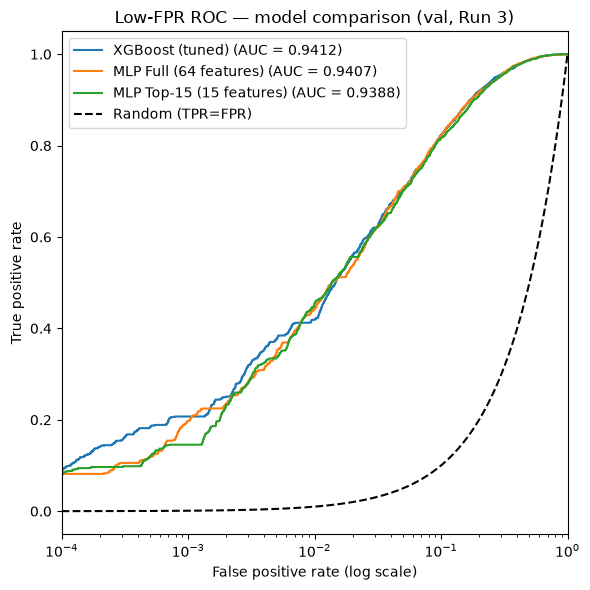

--- FPR = 1e-03 (~112 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.2071  (207x random lift)
  MLP Full (64 features)           TPR = 0.1975  (198x random lift)
  MLP Top-15 (15 features)         TPR = 0.1455  (145x random lift)
--- FPR = 1e-02 (~1120 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4187  (42x random lift)
  MLP Full (64 features)           TPR = 0.4422  (44x random lift)
  MLP Top-15 (15 features)         TPR = 0.4544  (45x random lift)


In [ ]:
# ---- Load a tuned XGBoost fold-0 model (same Run 3 track, k-fold artifacts
# from Esteban/1L2Tau_Master_Pipeline.ipynb) for an apples-to-apples overlay.
import xgboost as xgb

xgb_model_run3 = xgb.XGBClassifier()
xgb_model_run3.load_model(BASE_DIR_RUN3 / "model_run3_fold0.json")
with open(BASE_DIR_RUN3 / "features_run3.json") as f:
    xgb_features_run3 = json.load(f)

xgb_val_scores_run3 = xgb_model_run3.predict_proba(fd0_run3["val_df"][xgb_features_run3])[:, 1]

fpr_val_run3, tpr_val_run3, _ = roc_curve(y_val_run3, val_scores_run3, sample_weight=w_val_abs_run3)

curves_run3 = {
    "XGBoost (tuned, fold 0)": roc_with_auc(y_val_run3, xgb_val_scores_run3, w_val_abs_run3),
    f"MLP Full ({len(features_run3)} features)": roc_with_auc(y_val_run3, val_probs_run3, w_val_abs_run3),
    f"MLP {best_name_run3}": (fpr_val_run3, tpr_val_run3, final_val_auc_run3),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_run3.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Run 3, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_run3 = int((y_val_run3 == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_run3:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_run3.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")


In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert torch.isfinite(fd0_run3["X_train_t"]).all() and torch.isfinite(fd0_run3["X_val_t"]).all(), \
    "NaN/inf reached the model input (Run 3)"

set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    fd0_run3["X_train_t"], fd0_run3["y_train_t"], fd0_run3["w_train_fit_t"],
    fd0_run3["X_val_t"], fd0_run3["y_val_t"], fd0_run3["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED: {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

summary_run3 = pd.DataFrame([{
    "model": best_name_run3,
    "train_auc_eval": final_train_auc_eval_run3,
    "val_auc": final_val_auc_run3,
    "max_asimov_Z (val)": z_val_run3,
}])

print("\nFold-0-preview summary (MLP, 1l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3


Determinism check passed: two re-seeded runs give identical val_auc = 0.901489

Final summary (MLP, 1l2tau Run 3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)
Top-15 (15 features)        0.939714 0.938795            0.021352


,model,train_auc_eval,val_auc,max_asimov_Z (val)
0,Top-15 (15 features),0.939714,0.938795,0.021352


## K-Fold Production Run & Artifacts (Run 3)

Same as the Run 2 section: `run_kfold_nn` trains one model per fold (frozen
tuned hyperparameters, `best_params_run3`, on `FINAL_FEATURES_R3`) and
scores every event with a model that never trained on it.


In [ ]:
# ---- K-FOLD PRODUCTION RUN (Run 3) -----------------------------------------
flag_cols_final_run3 = [f for f in flag_cols_run3 if f in FINAL_FEATURES_R3]

oof_df_run3, models_run3, scalers_run3, medians_run3 = run_kfold_nn(
    data_run3, FINAL_FEATURES_R3, flag_cols_final_run3, best_params_run3, target_yields_run3,
    cell_cols=(), n_folds=N_FOLDS, label="Run3",
)

oof_auc_run3 = plot_oof_roc(oof_df_run3, title="1l2tau Run 3 (MLP) - OOF ROC")

save_track_artifacts_nn(
    models_run3, scalers_run3, medians_run3, FINAL_FEATURES_R3, flag_cols_final_run3,
    best_params_run3, oof_df_run3, BASE_DIR_RUN3, "run3",
)


Final model: Top-15 (15 features)
Weighted AUC: val(holdout)=0.9388  test(held-out, scored once)=0.9408
Asimov Z at val-selected cut (0.9631, frozen): val=0.021  test=0.023


## Run 2 + Run 3 — Combined Track

Chains (concatenates) Run 2 and Run 3 events into a single training sample,
mirroring `1L2Tau_Master_Pipeline.ipynb`'s Section 5. The candidate feature
set is restricted to branches common to BOTH runs (the intersection of
`features_run2` and `features_run3`, equivalent to discovering common
branches across all process files in both directories). An extra `run`
bookkeeping column (2 or 3) is kept (never a training feature) so the
Run2/Run3 mix can be checked, and so the train/val split can be stratified
on `label` AND `run` jointly. Everything below uses `_comb`-suffixed
variable names so the Run 2 and Run 3 results above remain untouched.

In [ ]:
# Combined uses features common to BOTH runs (equivalent to discovering
# common branches across all process files in both directories).

candidate_features_comb = sorted(set(features_run2) & set(features_run3))

keep_cols_comb = candidate_features_comb + ["w_phys", "label", "process", EVENT_ID_BRANCH]

data_run2_tagged = data_run2[keep_cols_comb].copy()
data_run2_tagged["run"] = 2

data_run3_tagged = data_run3[keep_cols_comb].copy()
data_run3_tagged["run"] = 3

data_comb_raw = pd.concat([data_run2_tagged, data_run3_tagged], ignore_index=True)
data_comb, features_comb = clean_data(data_comb_raw, candidate_features_comb)
data_comb = assign_folds(data_comb)

print(f"\nCombined: {len(data_comb)} events, {len(features_comb)} features "
      f"(intersection of Run2's {len(features_run2)} and Run3's {len(features_run3)})")

for run_label in (2, 3):
    sub = data_comb[data_comb["run"] == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data_comb["fold"].value_counts().sort_index())


Dropped 0 constant/empty features:
  []

64 final features
Total: 2015576 events | signal = 293764 | background = 1721812
Yield (w_phys): signal = 3.91 | background = 30834.21

Combined: 2015576 events, 64 features (intersection of Run2's 64 and Run3's 64)
Run 2: signal yield = 1.82 | background yield = 11467.29 | n_events = 690684
Run 3: signal yield = 2.08 | background yield = 19366.92 | n_events = 1324892


## Sentinel Audit (-1) — Combined

Same diagnostic as the Run 2/Run 3 sections above, run on the combined
sample.

In [39]:
NEG1_SENTINEL_FEATURES_comb = set()

neg1_rows_comb = []
for f in features_comb:
    vals = data_comb[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_comb.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_comb = pd.DataFrame(neg1_rows_comb).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_comb)} / {len(features_comb)} features have at least one row exactly equal to -1:")
print(neg1_df_comb.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_comb:
    data_comb[f] = data_comb[f].mask(data_comb[f] == -1)
if NEG1_SENTINEL_FEATURES_comb:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_comb)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474537                      2.0

NEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.


## Train/Validation Split & Preprocessing — Combined

Same 80/20 split, but stratified on `label` AND `run` jointly (not just
`label`) so both partitions keep the same Run2/Run3 mix - `make_train_val_split`
doesn't support a joint stratify key, so the split is done inline here.
Preprocessing (median imputation, standard scaling, `__isnan` flags)
otherwise follows the same convention as the Run 2/Run 3 sections.

In [ ]:
# ---- Weight-balance diagnostics (Combined, representative fold 0) ---------
# Stratifying by "run" here (cell_cols=("run",)) balances signal vs
# background WITHIN each run separately before the global mean-normalization
# - stops whichever run has the most MC events from dominating the pooled
# loss (see make_fit_weights docstring).
BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")
PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)

target_yields_comb = compute_process_yield_targets(data_comb)
flag_cols_comb = compute_flag_cols(data_comb, features_comb)
N_FEATURES_MODEL = len(features_comb) + len(flag_cols_comb)

fd0_comb = prepare_fold_tensors(data_comb, features_comb, flag_cols_comb, target_yields_comb,
                                 cell_cols=("run",), n_folds=N_FOLDS, k=0)

w_before_comb = fd0_comb["train_df"]["w_phys"].to_numpy()
w_after_comb = fd0_comb["w_train_fit"]
y_preview_comb = fd0_comb["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview_comb, w_before_comb, w_after_comb,
    title="Combined (MLP) - make_fit_weights balancing (fold 0 train, per-run cell)",
    save_path=PLOTS_DIR_COMB / "CombinedWeightBalance_MLP.png",
)

print(f"{len(flag_cols_comb)} features had missing values in train (globally) -> added "
      f"{len(flag_cols_comb)} __isnan flag columns (final model input width = {N_FEATURES_MODEL} = "
      f"{len(features_comb)} features + {len(flag_cols_comb)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by run x label - fold 0:")
print(n_eff_table(fd0_comb["train_df"], ["run", "label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by run x label:")
print(n_eff_table(fd0_comb["test_df"], ["run", "label"]))
print(f"\nDropped {fd0_comb['n_dropped_train']} negative-w_phys training rows in this "
      f"preview fold (kept, not abs'd, elsewhere - see prepare_fold_data).")


Train: 1612460 events | signal = 235011 | background = 1377449
Val:   201558 events | signal = 29377 | background = 172181
Test:  201558 events | signal = 29376 | background = 172182  (held out until final evaluation)
Train run mix: {2: 552547, 3: 1059913}
Val   run mix: {2: 69069, 3: 132489}
Test  run mix: {2: 69068, 3: 132490}

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 64 = 64 features + 0 flags)
Dropped 171113/1612460 negative-w_phys training events (10.6%) - kept, not abs'd
Signal weight scale factor (train, post-filter): 9442.4


## PyTorch Dataset & Model — Combined

In [ ]:
model_comb = build_model(n_features=fd0_comb["n_features_model"])

print(model_comb)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Training Loop — Combined

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_comb` tensors passed in so the Run 2/Run 3
models/histories are untouched.

In [ ]:
# ---- Fold-0 preview baseline (default hyperparameters) ---------------------
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=(128, 64), w_train_eval_data=fd0_comb["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc_comb:.4f} | train_auc (dropout on) = {best_train_auc_comb:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_comb:.4f}")


Epoch   1 | train_loss=0.4404 val_loss=0.3932 | train_auc=0.8796 train_auc_eval=0.9112 val_auc=0.9156
Epoch   2 | train_loss=0.3918 val_loss=0.3498 | train_auc=0.9072 train_auc_eval=0.9177 val_auc=0.9213
Epoch   3 | train_loss=0.3784 val_loss=0.3330 | train_auc=0.9117 train_auc_eval=0.9219 val_auc=0.9247
Epoch   4 | train_loss=0.3684 val_loss=0.3645 | train_auc=0.9162 train_auc_eval=0.9254 val_auc=0.9264
Epoch   5 | train_loss=0.3617 val_loss=0.3503 | train_auc=0.9194 train_auc_eval=0.9271 val_auc=0.9281
Epoch   6 | train_loss=0.3568 val_loss=0.3238 | train_auc=0.9215 train_auc_eval=0.9287 val_auc=0.9290
Epoch   7 | train_loss=0.3566 val_loss=0.3421 | train_auc=0.9216 train_auc_eval=0.9295 val_auc=0.9297
Epoch   8 | train_loss=0.3533 val_loss=0.3339 | train_auc=0.9231 train_auc_eval=0.9307 val_auc=0.9304
Epoch   9 | train_loss=0.3491 val_loss=0.3511 | train_auc=0.9250 train_auc_eval=0.9319 val_auc=0.9311
Epoch  10 | train_loss=0.3473 val_loss=0.3219 | train_auc=0.9258 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Combined

In [ ]:
study_comb = run_optuna_search_nn(data_comb, features_comb, flag_cols_comb, target_yields_comb,
                                   cell_cols=("run",), study_name="mlp_opt_combined")
best_params_comb = params_from_study_nn(study_comb)
best_hidden_sizes_comb = best_params_comb["hidden_sizes"]
plot_optuna_diagnostics_nn(study_comb, title_suffix="(1l2tau, Combined, MLP)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters -------
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=best_params_comb["hidden_sizes"], dropout=best_params_comb["dropout"],
    lr=best_params_comb["lr"], weight_decay=best_params_comb["weight_decay"],
    batch_size=best_params_comb["batch_size"], patience=best_params_comb["patience"],
    w_train_eval_data=fd0_comb["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc_comb:.4f} | hidden_sizes={best_hidden_sizes_comb}")


hidden_sizes=(64,)            -> train_auc=0.9303 val_auc=0.9359
hidden_sizes=(128, 64)        -> train_auc=0.9376 val_auc=0.9396
hidden_sizes=(256, 128)       -> train_auc=0.9426 val_auc=0.9401
hidden_sizes=(128, 64, 32)    -> train_auc=0.9373 val_auc=0.9391
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9419 val_auc=0.9410

Best architecture: hidden_sizes=(256, 128, 64, 32) | val_auc=0.9410


## Evaluation — Combined

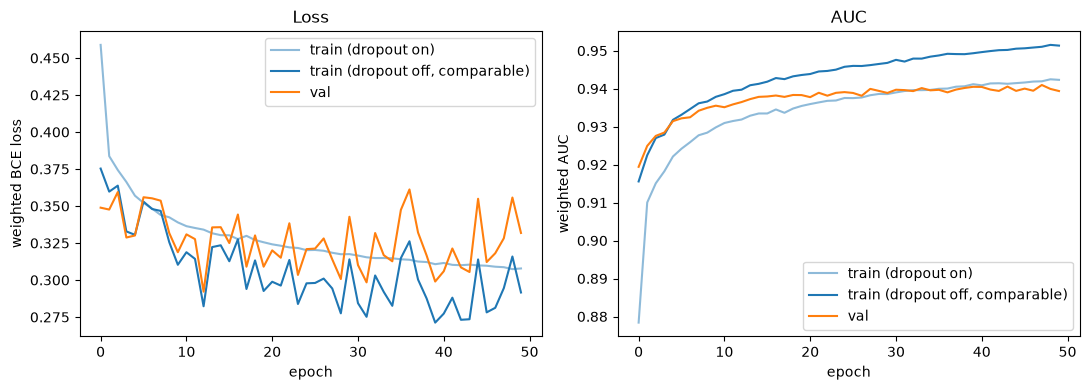

Final weighted AUC: train=0.9510 val=0.9410


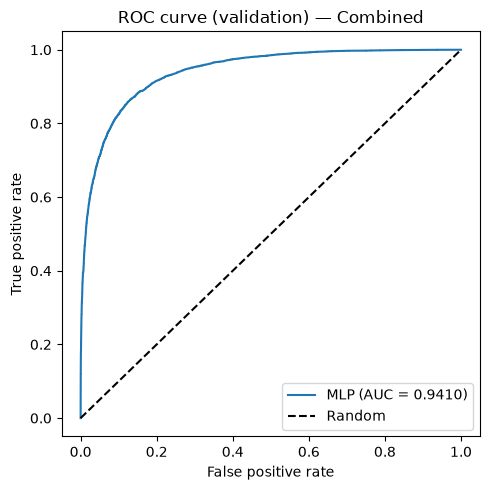

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_comb["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_comb["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_comb["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_comb["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_comb["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_comb["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_comb.eval()
with torch.no_grad():
    train_probs_comb = torch.sigmoid(model_comb(fd0_comb["X_train_t"])).cpu().numpy()
    val_probs_comb = torch.sigmoid(model_comb(fd0_comb["X_val_t"])).cpu().numpy()

y_train_comb, y_val_comb = fd0_comb["train_df"]["label"].to_numpy(), fd0_comb["val_df"]["label"].to_numpy()
w_train_abs_comb = fd0_comb["train_df"]["w_phys"].to_numpy()
w_val_abs_comb = np.abs(fd0_comb["val_df"]["w_phys"].to_numpy())

auc_train_comb = roc_auc_score(y_train_comb, train_probs_comb, sample_weight=w_train_abs_comb)
auc_val_comb = roc_auc_score(y_val_comb, val_probs_comb, sample_weight=w_val_abs_comb)

print(f"Final weighted AUC (fold-0 preview): train={auc_train_comb:.4f} val={auc_val_comb:.4f}")

fpr_comb, tpr_comb, _ = roc_curve(y_val_comb, val_probs_comb, sample_weight=w_val_abs_comb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_comb, tpr_comb, label=f"MLP (AUC = {auc_val_comb:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview) — Combined")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Permutation) — Combined

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9410
Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedImportanceFull_MLP.png


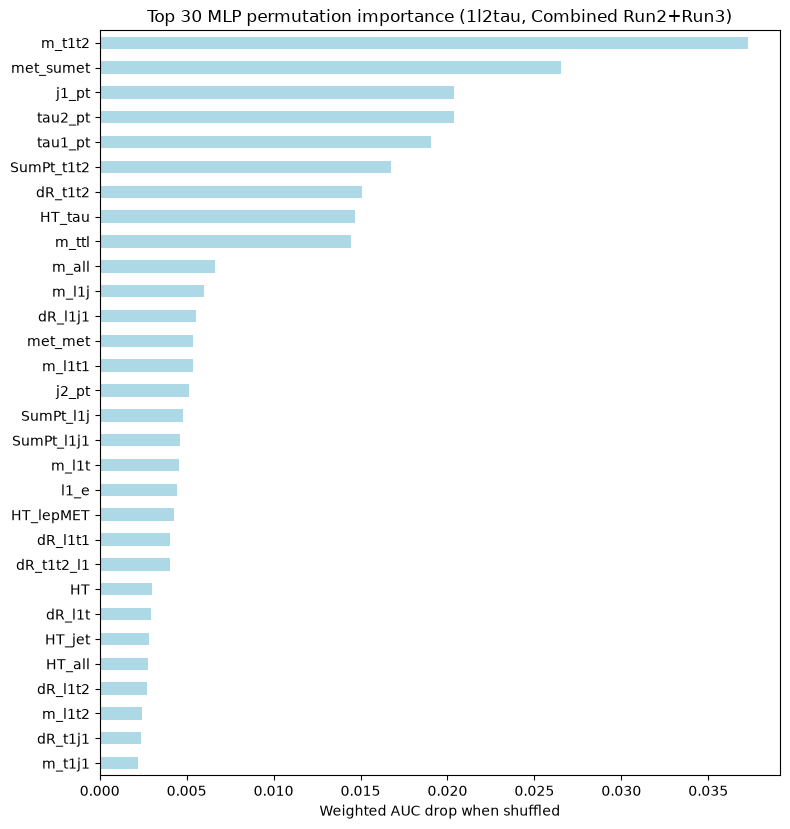

m_t1t2        0.037262
met_sumet     0.026524
j1_pt         0.020389
tau2_pt       0.020361
tau1_pt       0.019044
SumPt_t1t2    0.016762
dR_t1t2       0.015081
HT_tau        0.014684
m_ttl         0.014437
m_all         0.006650
m_l1j         0.005981
dR_l1j1       0.005530
met_met       0.005359
m_l1t1        0.005340
j2_pt         0.005162
Name: auc_drop, dtype: float64

In [ ]:
importance_comb = permutation_importance(model_comb, fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
                                          features_comb, n_repeats=5)
plot_importance_bar(importance_comb, top_n=30, title="Top 30 MLP permutation importance (1l2tau, Combined Run2+Run3, fold-0 preview)",
                     save_path=PLOTS_DIR_COMB / "CombinedImportanceFull_MLP.png")
importance_comb.head(15)


## Correlation Pruning & Retraining — Combined

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on the combined inputs).

Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedCorrelationTop30_MLP.png


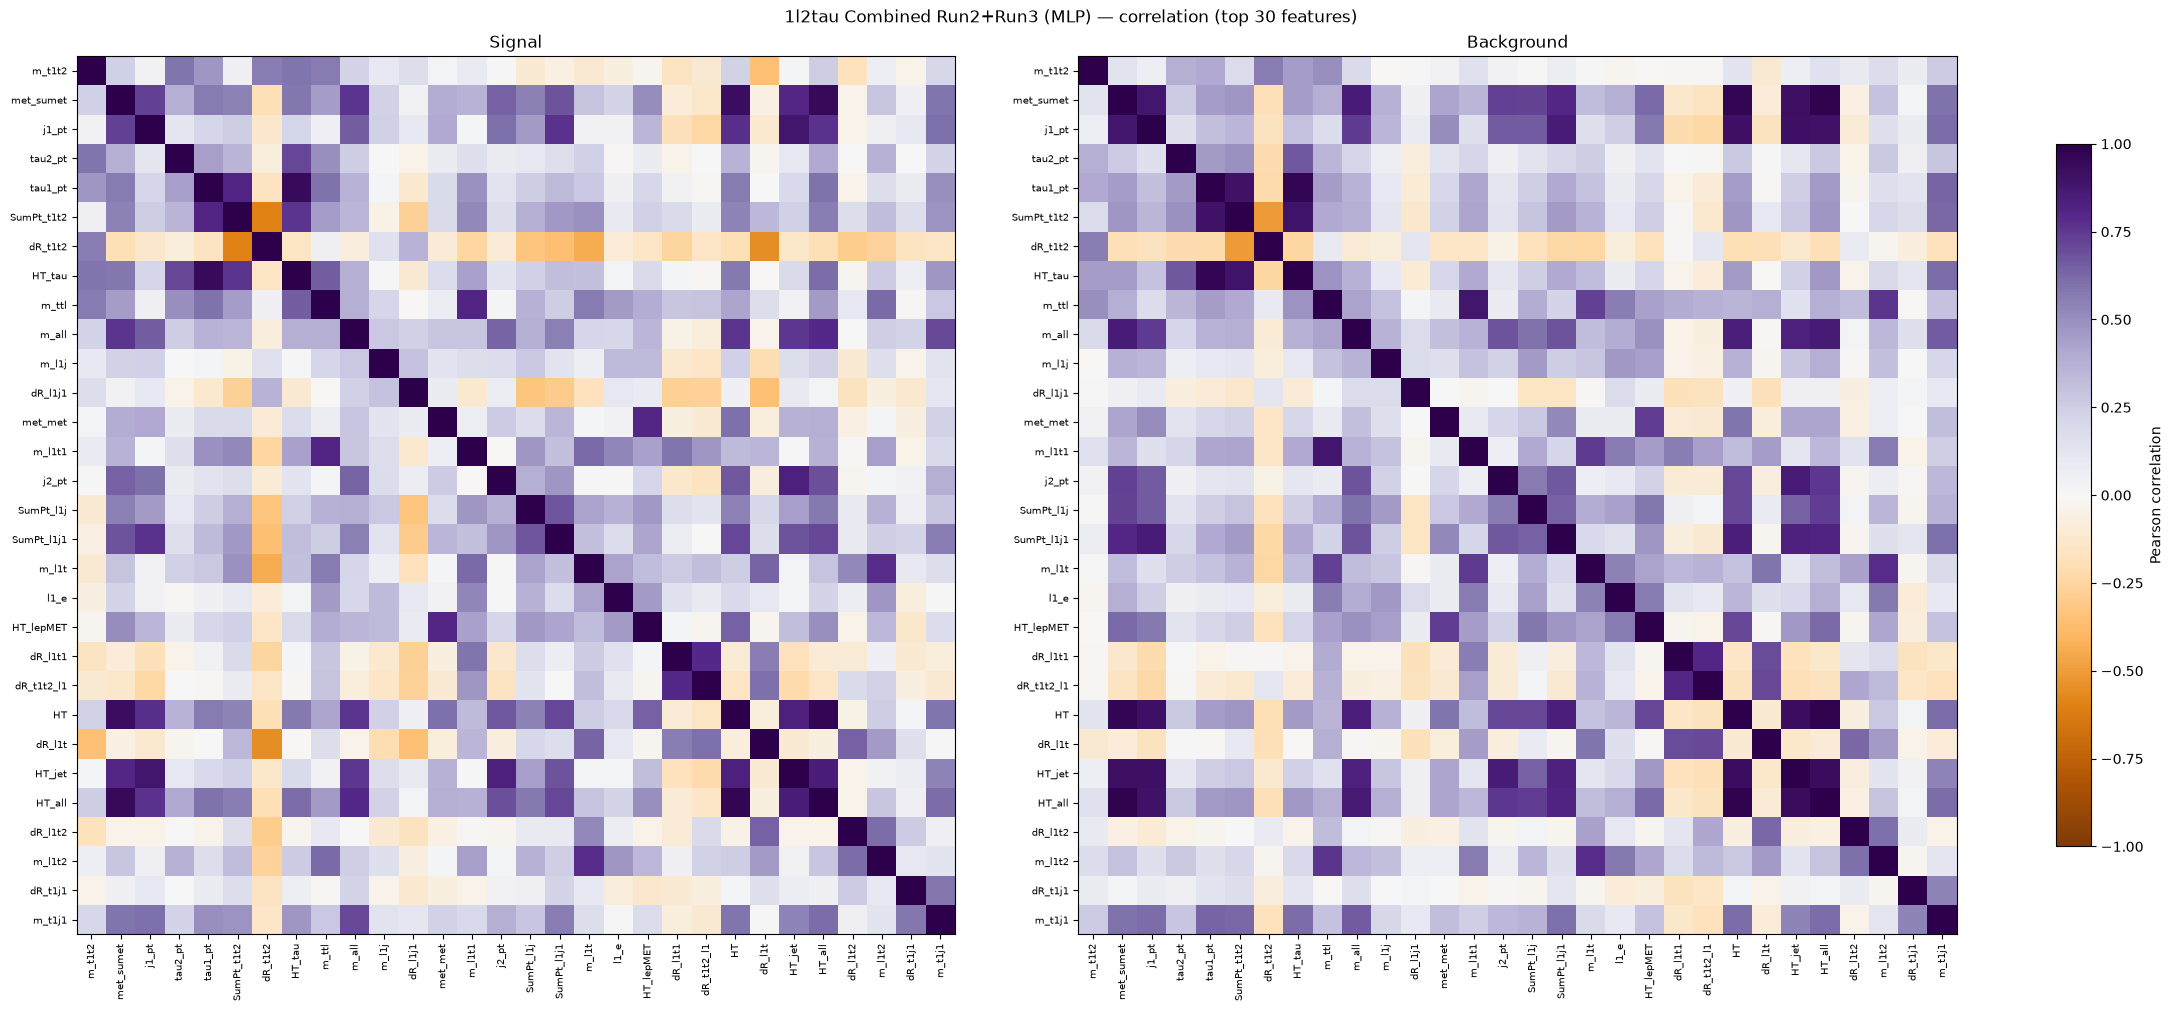

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.966265
met_sumet   HT_all        0.949262
tau1_pt     HT_tau        0.944697
met_sumet   HT            0.925993
j1_pt       HT_jet        0.880534
HT_jet      HT_all        0.850035
HT          HT_jet        0.834788
j2_pt       HT_jet        0.831624
tau1_pt     SumPt_t1t2    0.810478
m_ttl       m_l1t1        0.808434
met_sumet   HT_jet        0.801435
met_met     HT_lepMET     0.797994
dR_l1t1     dR_t1t2_l1    0.794381
m_all       HT_all        0.792123
m_l1t       m_l1t2        0.784638
j1_pt       HT            0.778276
            HT_all        0.773087
            SumPt_l1j1    0.768729
SumPt_t1t2  HT_tau        0.765479
m_all       HT            0.762113
met_sumet   m_all         0.758895
m_all       HT_jet        0.757153
met_sumet   j1_pt         0.733829
SumPt_l1j1  HT_all        0.717315
            HT            0.715588
tau2_pt     HT_tau        0.712720
m_all       m_t1j1        0.707748

Pairs with |corr| >

In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_comb = importance_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(fd0_comb["train_df"], top_feats_comb, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"1l2tau Combined Run2+Run3 (MLP) — correlation (top {TOP_N_IMPORTANCE} features, fold-0 preview)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationTop30_MLP.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())


In [47]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_comb, dropped_features_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)

Kept 18 decorrelated features (most -> least important):
   1. m_t1t2
   2. met_sumet
   3. tau2_pt
   4. tau1_pt
   5. dR_t1t2
   6. m_ttl
   7. m_l1j
   8. dR_l1j1
   9. met_met
  10. j2_pt
  11. SumPt_l1j
  12. m_l1t
  13. l1_e
  14. dR_l1t1
  15. dR_l1t
  16. dR_l1t2
  17. dR_t1j1
  18. m_t1j1

Dropped 12 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  m_all           -> redundant with met_sumet       (|corr| = 0.854)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.879)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.797)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.798)
  dR_t1t2_l1      -> redundant with dR_l1t1         (|corr| = 0.798)
  HT              -> redundant with met_sumet       (|corr| = 0.962)
  

Full model      (64 features): train_auc_eval = 0.9510 | val_auc = 0.9410
Pruned model     (18 features): train_auc_eval = 0.9421 | val_auc = 0.9394
Baseline weighted AUC: 0.9394
Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedImportancePruned_MLP.png


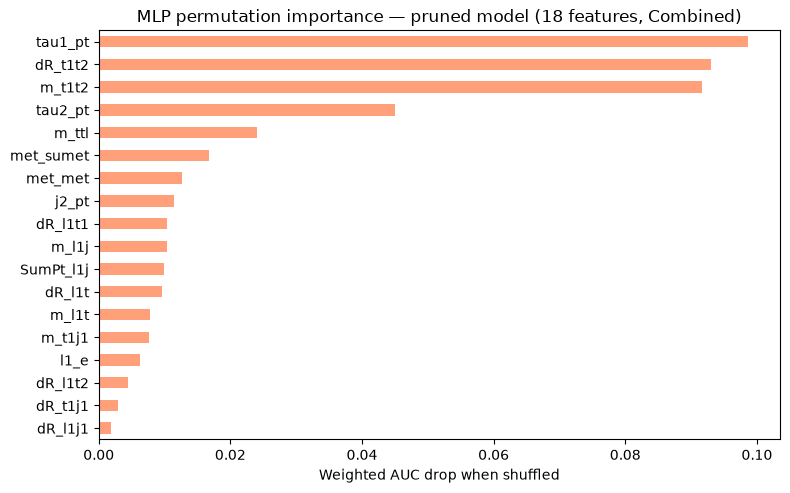

Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedCorrelationPruned_MLP.png


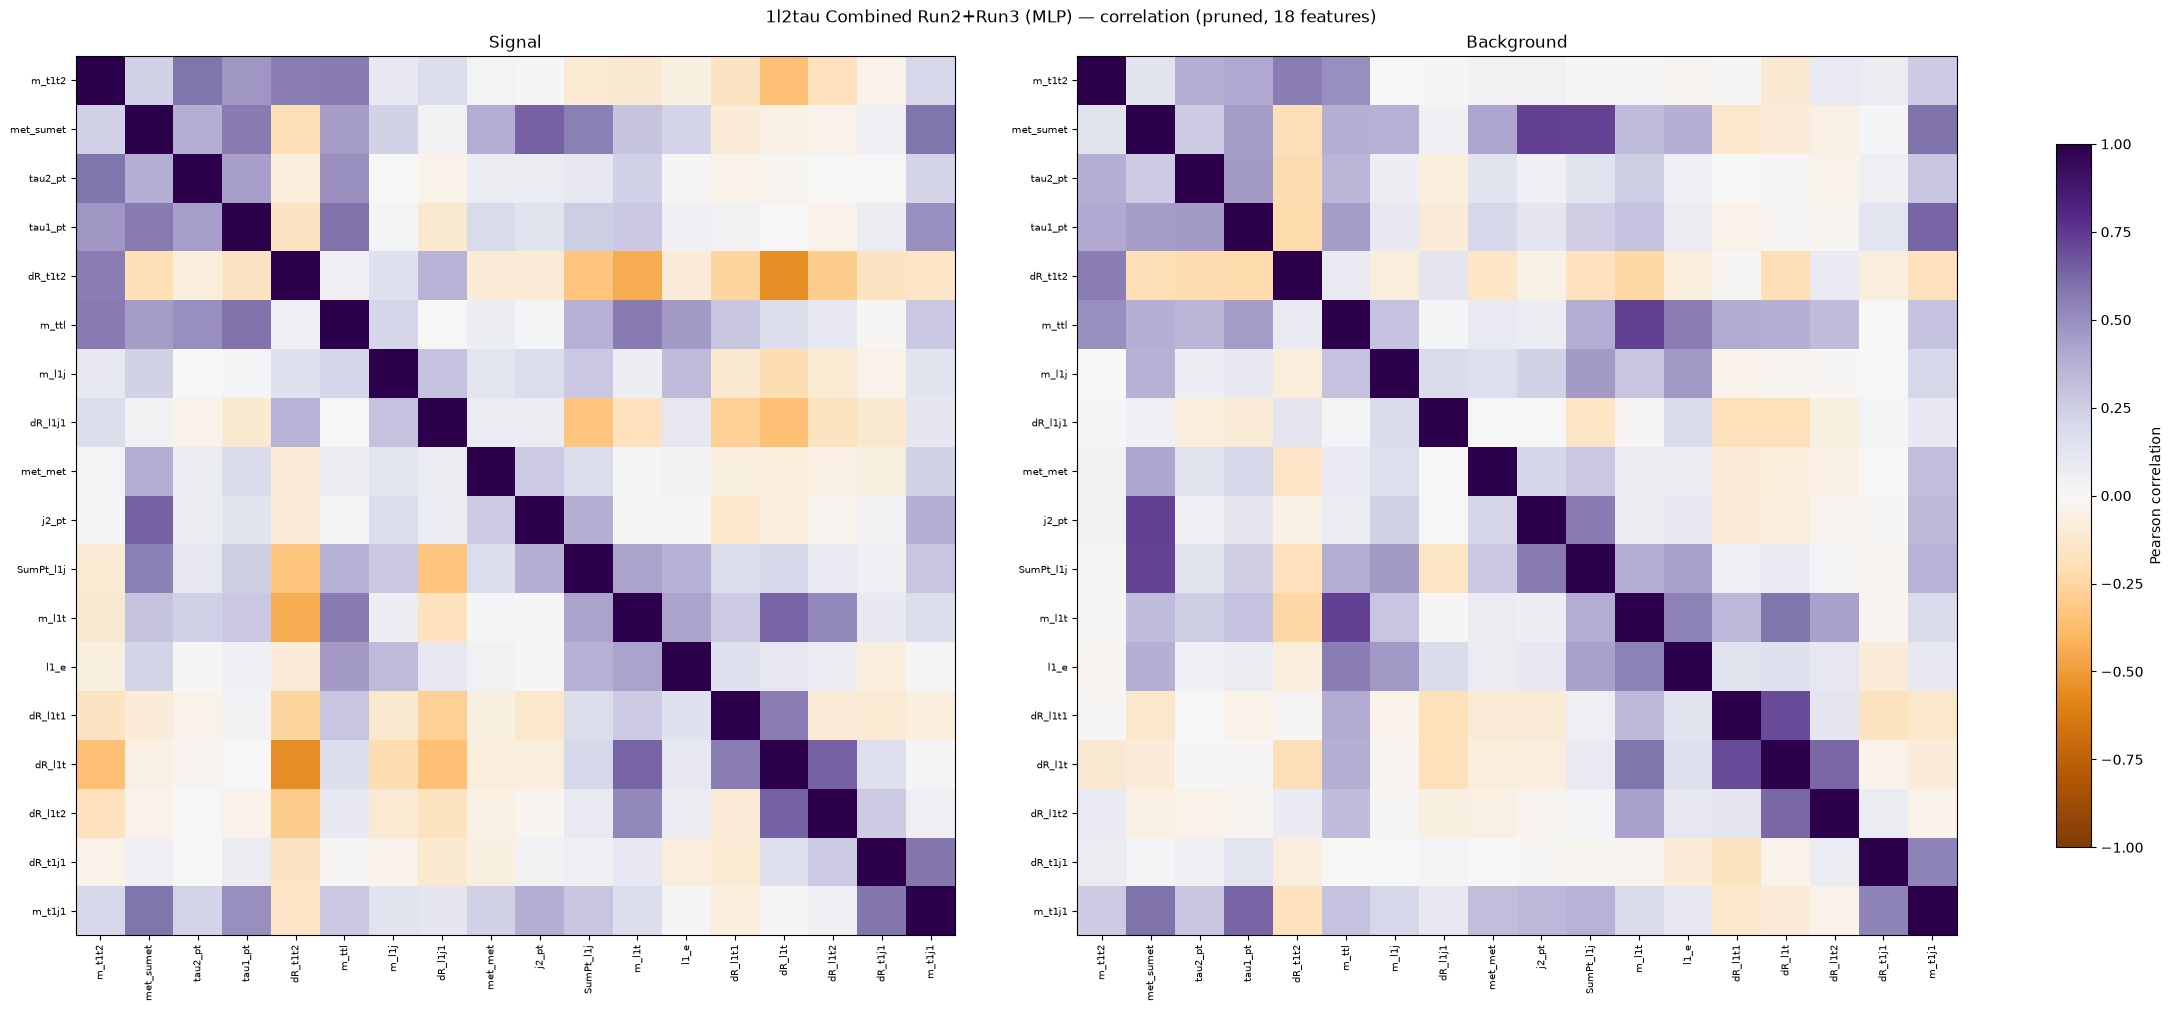

In [ ]:
# ---- Retrain on the pruned feature set (fold-0 preview) --------------------
X_train_pruned_t_comb, X_val_pruned_t_comb, X_test_pruned_t_comb = subset_feature_tensors_fold(fd0_comb, PRUNED_FEATURES_comb, features_comb)

model_pruned_comb, history_pruned_comb, val_auc_pruned_comb, train_auc_pruned_comb, train_auc_eval_pruned_comb = train_model(
    X_train_pruned_t_comb, fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    X_val_pruned_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_comb, dropout=best_params_comb["dropout"], lr=best_params_comb["lr"],
    weight_decay=best_params_comb["weight_decay"], batch_size=best_params_comb["batch_size"],
    patience=best_params_comb["patience"], w_train_eval_data=fd0_comb["w_train_abs_t"], verbose=False,
)

print(f"Full model      ({len(features_comb):2d} features): train_auc_eval = {best_train_auc_eval_comb:.4f} | val_auc = {best_val_auc_comb:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_comb):2d} features): train_auc_eval = {train_auc_eval_pruned_comb:.4f} | val_auc = {val_auc_pruned_comb:.4f}")

importance_pruned_comb = permutation_importance(model_pruned_comb, X_val_pruned_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
                                                 PRUNED_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_pruned_comb, top_n=len(PRUNED_FEATURES_comb),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES_comb)} features, Combined)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMB / "CombinedImportancePruned_MLP.png",
)

pruned_corrs_comb = grouped_correlations(fd0_comb["train_df"], PRUNED_FEATURES_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_comb[1], pruned_corrs_comb[0]], ["Signal", "Background"], PRUNED_FEATURES_comb,
    suptitle=f"1l2tau Combined Run2+Run3 (MLP) — correlation (pruned, {len(PRUNED_FEATURES_comb)} features, fold-0 preview)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationPruned_MLP.png",
)


## Top-15 Features Only — Combined

Kept 15 decorrelated features (most -> least important):
   1. m_t1t2
   2. met_sumet
   3. tau2_pt
   4. tau1_pt
   5. dR_t1t2
   6. m_ttl
   7. m_l1j
   8. dR_l1j1
   9. met_met
  10. j2_pt
  11. SumPt_l1j
  12. m_l1t
  13. l1_e
  14. dR_l1t1
  15. dR_l1t

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  m_all           -> redundant with met_sumet       (|corr| = 0.854)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.879)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.797)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.798)
  dR_t1t2_l1      -> redundant with dR_l1t1         (|corr| = 0.798)
  HT              -> redundant with met_sumet       (|corr| = 0.962)


Baseline weighted AUC: 0.9384
Saved plot -> PPSSP_2026/1l2tau/combined/plots/CombinedImportanceTop15_MLP.png


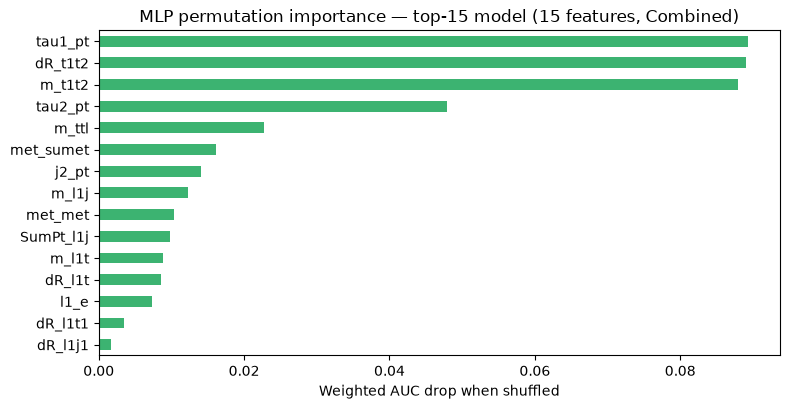


Weighted train(eval-mode)/validation AUC comparison (Combined):


,model,train_auc_eval,val_auc
0,Full (64 features),0.951028,0.940967
1,Pruned (18 features),0.942094,0.939362
2,Top-15 (15 features),0.940059,0.938419


In [ ]:
TOP15_FEATURES_comb, dropped_top15_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, n_keep=15)

X_train_top15_t_comb, X_val_top15_t_comb, X_test_top15_t_comb = subset_feature_tensors_fold(fd0_comb, TOP15_FEATURES_comb, features_comb)

model_top15_comb, history_top15_comb, val_auc_top15_comb, train_auc_top15_comb, train_auc_eval_top15_comb = train_model(
    X_train_top15_t_comb, fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    X_val_top15_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes_comb, dropout=best_params_comb["dropout"], lr=best_params_comb["lr"],
    weight_decay=best_params_comb["weight_decay"], batch_size=best_params_comb["batch_size"],
    patience=best_params_comb["patience"], w_train_eval_data=fd0_comb["w_train_abs_t"], verbose=False,
)

importance_top15_comb = permutation_importance(model_top15_comb, X_val_top15_t_comb, fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
                                                TOP15_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_top15_comb, top_n=len(TOP15_FEATURES_comb),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES_comb)} features, Combined)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_COMB / "CombinedImportanceTop15_MLP.png",
)

comparison_comb = pd.DataFrame([
    {"model": f"Full ({len(features_comb)} features)", "train_auc_eval": best_train_auc_eval_comb, "val_auc": best_val_auc_comb},
    {"model": f"Pruned ({len(PRUNED_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_pruned_comb, "val_auc": val_auc_pruned_comb},
    {"model": f"Top-15 ({len(TOP15_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_top15_comb, "val_auc": val_auc_top15_comb},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Combined, fold-0 preview):")
comparison_comb


## Physics Figure of Merit & Final Summary (Validation Set) — Combined

Reuses `significance_scan` from the Run 2 section. Same caveat applies:
`val_df_comb` is both the early-stopping/model-selection set and the set
scored here, so treat these numbers as relative/diagnostic for comparing
Combined models, not an absolute discovery-significance claim.

In [ ]:
# ---- Score the model with the best fold-0-preview val_auc (Full/Pruned/Top-15) -
FEATURE_SETS_COMB = {
    f"Full ({len(features_comb)} features)": (model_comb, features_comb, fd0_comb["X_val_t"]),
    f"Pruned ({len(PRUNED_FEATURES_comb)} features)": (model_pruned_comb, PRUNED_FEATURES_comb, X_val_pruned_t_comb),
    f"Top-15 ({len(TOP15_FEATURES_comb)} features)": (model_top15_comb, TOP15_FEATURES_comb, X_val_top15_t_comb),
}
best_name_comb = comparison_comb.iloc[0]["model"]
final_model_comb, FINAL_FEATURES_COMB, X_val_final_t_comb = FEATURE_SETS_COMB[best_name_comb]

final_model_comb.eval()
with torch.no_grad():
    val_scores_comb = torch.sigmoid(final_model_comb(X_val_final_t_comb)).cpu().numpy()

y_val_comb = fd0_comb["val_df"]["label"].to_numpy()
w_val_signed_comb = fd0_comb["val_df"]["w_phys"].to_numpy()

z_val_comb, thr_val_comb = significance_scan(y_val_comb, val_scores_comb, w_val_signed_comb)
final_val_auc_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "val_auc"].iloc[0]
final_train_auc_eval_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "train_auc_eval"].iloc[0]

print(f"Final feature set (fold-0 preview): {best_name_comb}")
print(f"Weighted val AUC = {final_val_auc_comb:.4f}")
print(f"Max Asimov Z (val) = {z_val_comb:.3f} at score cut = {thr_val_comb:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9384
Max Asimov Z (val) = 0.044 at score cut = 0.9918


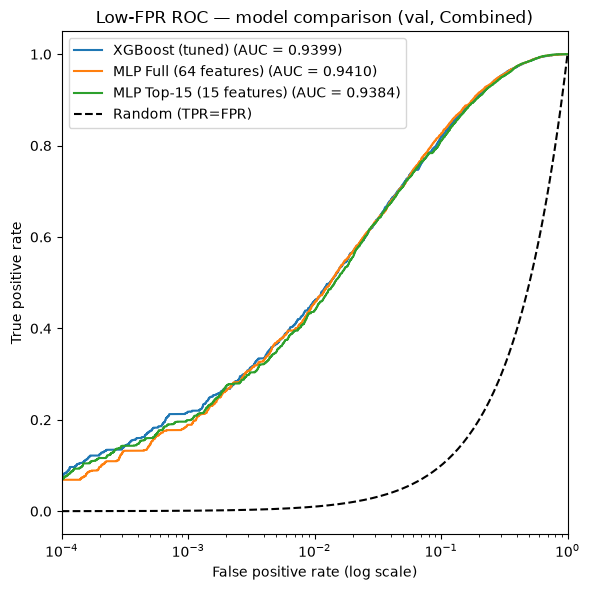

--- FPR = 1e-03 (~172 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.2177  (218x random lift)
  MLP Full (64 features)           TPR = 0.1891  (189x random lift)
  MLP Top-15 (15 features)         TPR = 0.1993  (199x random lift)
--- FPR = 1e-02 (~1722 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4599  (46x random lift)
  MLP Full (64 features)           TPR = 0.4562  (46x random lift)
  MLP Top-15 (15 features)         TPR = 0.4389  (44x random lift)


In [ ]:
# ---- Load a tuned XGBoost fold-0 model (Combined Run2+Run3 track, k-fold
# artifacts from Esteban/1L2Tau_Master_Pipeline.ipynb) for an apples-to-apples
# overlay, scored on this notebook's fold-0 val partition.
import xgboost as xgb

BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")

xgb_model_comb = xgb.XGBClassifier()
xgb_model_comb.load_model(BASE_DIR_COMB / "model_combined_fold0.json")
with open(BASE_DIR_COMB / "features_combined.json") as f:
    xgb_features_comb = json.load(f)

xgb_val_scores_comb = xgb_model_comb.predict_proba(fd0_comb["val_df"][xgb_features_comb])[:, 1]

fpr_val_comb, tpr_val_comb, _ = roc_curve(y_val_comb, val_scores_comb, sample_weight=w_val_abs_comb)

curves_comb = {
    "XGBoost (tuned, fold 0)": roc_with_auc(y_val_comb, xgb_val_scores_comb, w_val_abs_comb),
    f"MLP Full ({len(features_comb)} features)": roc_with_auc(y_val_comb, val_probs_comb, w_val_abs_comb),
    f"MLP {best_name_comb}": (fpr_val_comb, tpr_val_comb, final_val_auc_comb),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_comb.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Combined, fold-0 preview)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_comb = int((y_val_comb == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_comb:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_comb.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")


In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert torch.isfinite(fd0_comb["X_train_t"]).all() and torch.isfinite(fd0_comb["X_val_t"]).all(), \
    "NaN/inf reached the model input (Combined)"

set_seed(RANDOM_STATE)
_, _, det_check_a_comb, _, _ = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_comb, _, _ = train_model(
    fd0_comb["X_train_t"], fd0_comb["y_train_t"], fd0_comb["w_train_fit_t"],
    fd0_comb["X_val_t"], fd0_comb["y_val_t"], fd0_comb["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)
assert det_check_a_comb == det_check_b_comb, f"Determinism check FAILED: {det_check_a_comb} != {det_check_b_comb}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_comb:.6f}")

summary_comb = pd.DataFrame([{
    "model": best_name_comb,
    "train_auc_eval": final_train_auc_eval_comb,
    "val_auc": final_val_auc_comb,
    "max_asimov_Z (val)": z_val_comb,
}])

print("\nFold-0-preview summary (MLP, 1l2tau Combined Run2+Run3):")
summary_comb


Determinism check passed: two re-seeded runs give identical val_auc = 0.924365

Final summary (MLP, 1l2tau Combined Run2+Run3):


,model,train_auc_eval,val_auc,max_asimov_Z (val)
0,Top-15 (15 features),0.940059,0.938419,0.043516


## K-Fold Production Run & Artifacts (Combined)

Same as the Run 2/Run 3 sections: `run_kfold_nn` trains one model per fold
(frozen tuned hyperparameters, `best_params_comb`, on `FINAL_FEATURES_COMB`,
per-run cell-balanced via `cell_cols=("run",)`) and scores every event with
a model that never trained on it.


In [ ]:
# ---- K-FOLD PRODUCTION RUN (Combined) --------------------------------------
flag_cols_final_comb = [f for f in flag_cols_comb if f in FINAL_FEATURES_COMB]

oof_df_comb, models_comb, scalers_comb, medians_comb = run_kfold_nn(
    data_comb, FINAL_FEATURES_COMB, flag_cols_final_comb, best_params_comb, target_yields_comb,
    cell_cols=("run",), n_folds=N_FOLDS, label="Combined",
)

oof_auc_comb = plot_oof_roc(oof_df_comb, title="1l2tau Combined Run2+Run3 (MLP) - OOF ROC")

save_track_artifacts_nn(
    models_comb, scalers_comb, medians_comb, FINAL_FEATURES_COMB, flag_cols_final_comb,
    best_params_comb, oof_df_comb, BASE_DIR_COMB, "combined",
)


Final model: Top-15 (15 features)
Weighted AUC: val(holdout)=0.9384  test(held-out, scored once)=0.9373
Asimov Z at val-selected cut (0.9918, frozen): val=0.044  test=0.038
Test run mix: {2: 69068, 3: 132490}


## Run 2 vs Run 3 — Domain-Shift Check

Self-contained check, independent of the MLP models above - it only reuses
the Combined track's tuned, decorrelated **feature list** persisted by
`1L2Tau_Master_Pipeline.ipynb` (`PPSSP_2026/1l2tau/combined/
optuna_features_combined.json`), since the question ("do Run 2 and Run 3
agree on the features that matter") is about the input data, not about
which downstream classifier (XGBoost/MLP/DNN) is used. Methodology,
outputs and file paths are identical to the XGBoost master pipeline's
Section 6/7 (same bootstrap-CI forest plot + AUC-tolerance pooling-decision
plot), so results are directly comparable rather than a near-duplicate
under a different name.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS. **Reading the AUC:** ≈0.5 = indistinguishable runs;
well above 0.5 = a genuine shift, `AUC - 0.5` ≈ effect size.


In [ ]:
# ---- Setup: load the Combined track's tuned feature list + Run2/Run3 signal events
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary.csv")

BASE_DIR_COMB_DOMAIN = Path("PPSSP_2026/1l2tau/combined")
with open(BASE_DIR_COMB_DOMAIN / "features_combined.json") as f:
    domain_features = json.load(f)
print(f"Loaded {len(domain_features)} features from {BASE_DIR_COMB_DOMAIN / 'features_combined.json'}")

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"

frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_RUN2), (1, "Run 3", BASE_DIR_RUN3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
for feat in domain_features:
    m = domain_data[feat] < -100
    if m.any():
        domain_data[feat] = domain_data[feat].mask(m)

X_domain = domain_data[domain_features]
y_domain = domain_data["run_label"].to_numpy()
w_domain_raw = domain_data[WEIGHT_BRANCH].to_numpy()
w_domain_abs = np.abs(w_domain_raw)

w_domain_fit = w_domain_abs.copy()
sum_r2, sum_r3 = w_domain_fit[y_domain == 0].sum(), w_domain_fit[y_domain == 1].sum()
w_domain_fit[y_domain == 1] *= sum_r2 / sum_r3
w_domain_fit *= len(w_domain_fit) / w_domain_fit.sum()


def bootstrap_weighted_auc_ci(y, pred, w_abs, n_boot=1000, ci=0.95, random_state=RANDOM_STATE):
    """Percentile bootstrap CI for a weighted AUC over out-of-fold
    predictions - see 1L2Tau_Master_Pipeline.ipynb Section 6 for the
    full derivation/verification of this O(n) resample trick."""
    rng = np.random.default_rng(random_state)
    y, pred, w_abs = np.asarray(y), np.asarray(pred), np.asarray(w_abs)
    n = len(y)
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    order = np.argsort(pred, kind="stable")
    y_s, w_s = y[order], w_abs[order]
    y_desc = y_s[::-1]
    pred_desc = pred[order][::-1]
    is_pos_desc = y_desc == 1
    distinct_desc = np.empty(n, dtype=bool)
    distinct_desc[:-1] = pred_desc[:-1] != pred_desc[1:]
    distinct_desc[-1] = True

    boot_aucs = []
    attempts = 0
    while len(boot_aucs) < n_boot and attempts < n_boot * 20:
        attempts += 1
        idx = rng.integers(0, n, n)
        counts = np.bincount(idx, minlength=n)
        eff_w_desc = (w_s * counts[order])[::-1]
        tp_weight = np.where(is_pos_desc, eff_w_desc, 0.0)
        fp_weight = np.where(~is_pos_desc, eff_w_desc, 0.0)
        cum_tp, cum_fp = np.cumsum(tp_weight), np.cumsum(fp_weight)
        total_tp, total_fp = cum_tp[-1], cum_fp[-1]
        if total_tp == 0 or total_fp == 0:
            continue
        tpr = np.concatenate(([0.0], cum_tp[distinct_desc] / total_tp))
        fpr = np.concatenate(([0.0], cum_fp[distinct_desc] / total_fp))
        boot_aucs.append(trapz(tpr, fpr))

    boot_aucs = np.array(boot_aucs)
    lo, hi = np.percentile(boot_aucs, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return lo, hi, boot_aucs


# ---- Stratified K-Fold with out-of-fold predictions (no early stopping - see master pipeline notes) --
N_FOLDS_DOMAIN = 5
cv_domain = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)
domain_fold_aucs = []
oof_pred_signal = np.full(len(y_domain), np.nan)

for fold, (idx_tr, idx_te) in enumerate(cv_domain.split(X_domain, y_domain), start=1):
    fold_model = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    fold_model.fit(X_domain.iloc[idx_tr], y_domain[idx_tr], sample_weight=w_domain_fit[idx_tr])
    pred = fold_model.predict_proba(X_domain.iloc[idx_te])[:, 1]
    oof_pred_signal[idx_te] = pred
    fold_auc = roc_auc_score(y_domain[idx_te], pred, sample_weight=w_domain_abs[idx_te])
    domain_fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

domain_fold_aucs = np.array(domain_fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {domain_fold_aucs.mean():.4f} \u00b1 {domain_fold_aucs.std():.4f}")

ci_lo_signal, ci_hi_signal, _ = bootstrap_weighted_auc_ci(y_domain, oof_pred_signal, w_domain_abs, n_boot=2000)
print(f"Bootstrap 95% CI on OOF weighted AUC: [{ci_lo_signal:.4f}, {ci_hi_signal:.4f}]")


Loaded 20 features from PPSSP_2026/1l2tau/combined/optuna_features_combined.json
Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection


Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection
Fold 1/5: weighted AUC = 0.5308
Fold 2/5: weighted AUC = 0.5401
Fold 3/5: weighted AUC = 0.5366
Fold 4/5: weighted AUC = 0.5345
Fold 5/5: weighted AUC = 0.5347

Mean weighted AUC across 5 folds: 0.5353 ± 0.0030
Bootstrap 95% CI on OOF weighted AUC: [0.5325, 0.5379]


In [55]:
# ---- All-processes scan: repeat the two-sample test for every process ------
def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3, n_estimators=200):
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_RUN2), (1, BASE_DIR_RUN3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())
    X_proc, y_proc = data[features], data["run_label"].to_numpy()
    w_abs_proc = np.abs(data[WEIGHT_BRANCH].to_numpy())

    w_fit_proc = w_abs_proc.copy()
    sum_r2p, sum_r3p = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_r2p > 0 and sum_r3p > 0:
        w_fit_proc[y_proc == 1] *= sum_r2p / sum_r3p
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    oof_pred_proc = np.full(len(y_proc), np.nan)
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fm = xgb.XGBClassifier(n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
                                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
            fm.fit(X_proc.iloc[idx_tr], y_proc[idx_tr], sample_weight=w_fit_proc[idx_tr])
            pred = fm.predict_proba(X_proc.iloc[idx_te])[:, 1]
            oof_pred_proc[idx_te] = pred
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan
    if n_splits >= 2:
        ci_lo, ci_hi, _ = bootstrap_weighted_auc_ci(y_proc, oof_pred_proc, w_abs_proc, n_boot=1000)
    else:
        ci_lo = ci_hi = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds)")

    return {"process": process_name, "n_run2": n_r2, "n_run3": n_r3,
            "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
            "ci_lo": ci_lo, "ci_hi": ci_hi}


results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]
results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)
print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
results_df


signal_ggF  : Run2 =   67075 | Run3 =  191580 | weighted AUC = 0.5342 ± 0.0018 (3 folds)
signal_VBF  : Run2 =   21639 | Run3 =   13470 | weighted AUC = 0.5072 ± 0.0018 (3 folds)
Diboson     : Run2 =  312600 | Run3 =  628676 | weighted AUC = 0.5355 ± 0.0007 (3 folds)
Zjets       : Run2 =  141863 | Run3 =  157073 | weighted AUC = 0.5599 ± 0.0022 (3 folds)
Wjets       : Run2 =   31272 | Run3 =   39061 | weighted AUC = 0.5491 ± 0.0084 (3 folds)
ttbar       : Run2 =    7335 | Run3 =   40832 | weighted AUC = 0.5399 ± 0.0029 (3 folds)
tops        : Run2 =   62238 | Run3 =  161226 | weighted AUC = 0.5374 ± 0.0046 (3 folds)
SingleH     : Run2 =   11124 | Run3 =   38425 | weighted AUC = 0.5743 ± 0.0153 (3 folds)
Vgamma      : Run2 =   21510 | Run3 =   14295 | weighted AUC = 0.5255 ± 0.0136 (3 folds)
VVV         : Run2 =   14028 | Run3 =   40254 | weighted AUC = 0.5726 ± 0.0057 (3 folds)

Saved AUC summary (10 processes) -> run2_vs_run3_auc_summary.csv


,process,n_run2,n_run3,n_folds,mean_auc,std_auc,ci_lo,ci_hi
0,SingleH,11124,38425,3,0.574342,0.015287,0.559072,0.588395
1,VVV,14028,40254,3,0.572614,0.005670,0.565411,0.580181
2,Zjets,141863,157073,3,0.559877,0.002237,0.553732,0.565519
3,Wjets,31272,39061,3,0.549115,0.008450,0.535713,0.562398
4,ttbar,7335,40832,3,0.539880,0.002900,0.530889,0.548801
5,tops,62238,161226,3,0.537377,0.004618,0.516911,0.558236
6,Diboson,312600,628676,3,0.535466,0.000743,0.533150,0.537898
7,signal_ggF,67075,191580,3,0.534243,0.001794,0.531671,0.536927
8,Vgamma,21510,14295,3,0.525545,0.013615,0.500710,0.550298
9,signal_VBF,21639,13470,3,0.507238,0.001751,0.500413,0.514167


Saved plot -> PPSSP_2026/1l2tau/summary_plots/AUCSummaryDomainShiftForestPlot_MLP.png


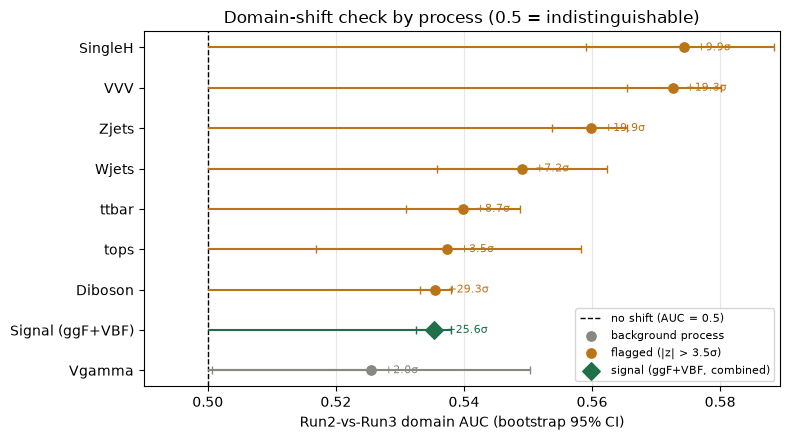


Flagged at |z| > 3.5σ:
         process  mean_auc         z
Signal (ggF+VBF)  0.535304 25.604046
         Diboson  0.535466 29.281275
            tops  0.537377  3.545531
           ttbar  0.539880  8.727898
           Wjets  0.549115  7.214958
           Zjets  0.559877 19.913455
             VVV  0.572614 19.272261
         SingleH  0.574342  9.938302


In [56]:
# ---- Forest plot (0.5 = good) + pooling-decision plot -----------------------
PLOTS_DIR_SUMMARY = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

is_signal_process = results_df["process"].map(lambda p: FILES.get(p, (None, 0))[1] == 1)
forest_df = results_df.loc[~is_signal_process].dropna(subset=["ci_lo", "ci_hi"]).copy()
forest_df["se"] = (forest_df["ci_hi"] - forest_df["ci_lo"]) / (2 * 1.96)
forest_df["z"] = (forest_df["mean_auc"] - 0.5) / forest_df["se"]

se_signal = (ci_hi_signal - ci_lo_signal) / (2 * 1.96)
signal_row = pd.DataFrame([{
    "process": "Signal (ggF+VBF)", "mean_auc": domain_fold_aucs.mean(),
    "ci_lo": ci_lo_signal, "ci_hi": ci_hi_signal,
    "z": (domain_fold_aucs.mean() - 0.5) / se_signal,
}])
plot_df_forest = pd.concat(
    [forest_df[["process", "mean_auc", "ci_lo", "ci_hi", "z"]], signal_row], ignore_index=True
).sort_values("mean_auc").reset_index(drop=True)

Z_THRESH = 3.5
is_sig_f = (plot_df_forest["process"] == "Signal (ggF+VBF)").to_numpy()
flag_f = (plot_df_forest["z"].abs() > Z_THRESH).to_numpy()
group_f = np.where(is_sig_f, "signal", np.where(flag_f, "flagged", "normal"))
GROUP_STYLE = {
    "normal":  dict(color="#888780", marker="o", size=45, label="background process"),
    "flagged": dict(color="#BA7517", marker="o", size=45, label=f"flagged (|z| > {Z_THRESH}\u03c3)"),
    "signal":  dict(color="#1f6f4a", marker="D", size=80, label="signal (ggF+VBF, combined)"),
}

y_pos = np.arange(len(plot_df_forest))
mean_auc_f = plot_df_forest["mean_auc"].to_numpy()
xerr_lo = (plot_df_forest["mean_auc"] - plot_df_forest["ci_lo"]).clip(lower=0).to_numpy()
xerr_hi = (plot_df_forest["ci_hi"] - plot_df_forest["mean_auc"]).clip(lower=0).to_numpy()

fig, ax = plt.subplots(figsize=(8, max(4.5, 0.42 * len(plot_df_forest))))
ax.axvline(0.5, color="k", lw=1, ls="--", label="no shift (AUC = 0.5)")
for g, style in GROUP_STYLE.items():
    mask = group_f == g
    if not mask.any():
        continue
    c = style["color"]
    ax.hlines(y_pos[mask], 0.5, mean_auc_f[mask], color=c, lw=1.5, zorder=2)
    ax.errorbar(mean_auc_f[mask], y_pos[mask], xerr=[xerr_lo[mask], xerr_hi[mask]],
                fmt="none", ecolor=c, capsize=3, zorder=2)
    ax.scatter(mean_auc_f[mask], y_pos[mask], color=c, s=style["size"], marker=style["marker"],
               zorder=3, label=style["label"])
for yi, z in zip(y_pos, plot_df_forest["z"]):
    ax.text(mean_auc_f[yi] + 0.002, yi, f"{z:+.1f}\u03c3", va="center", fontsize=8,
            color=GROUP_STYLE[group_f[yi]]["color"])
ax.set(yticks=y_pos, yticklabels=plot_df_forest["process"],
       xlim=(0.49, max(0.56, mean_auc_f.max() + 0.015)),
       xlabel="Run2-vs-Run3 domain AUC (bootstrap 95% CI)",
       title="Domain-shift check by process (0.5 = indistinguishable)")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
forest_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryDomainShiftForestPlot_MLP.png"
fig.savefig(forest_plot_path, dpi=150)
print(f"Saved plot -> {forest_plot_path}")
plt.show()

flagged = plot_df_forest.loc[plot_df_forest["z"].abs() > Z_THRESH, ["process", "mean_auc", "z"]]
print(f"\nFlagged at |z| > {Z_THRESH}\u03c3:")
print(flagged.to_string(index=False) if len(flagged) else "  none")


Saved plot -> PPSSP_2026/1l2tau/summary_plots/AUCSummaryDomainShiftPoolingCheck_MLP.png


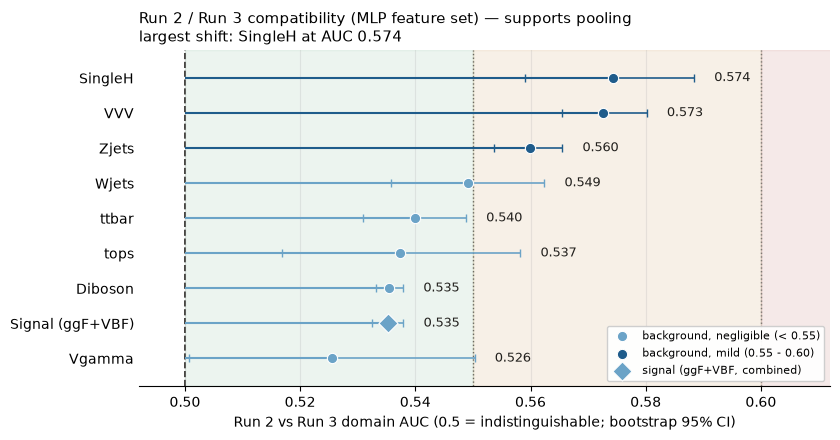


Max domain AUC = 0.574  (tolerance 0.6)
Verdict: supports pooling


In [57]:
# ---- Domain-shift plot: can Run 2 and Run 3 be pooled? ----------------------
AUC_NEGLIGIBLE = 0.55
AUC_TOLERABLE = 0.60

bkg_df = results_df.loc[~is_signal_process].dropna(subset=["ci_lo", "ci_hi"]).copy()
signal_row_pool = pd.DataFrame([{
    "process": "Signal (ggF+VBF)", "mean_auc": domain_fold_aucs.mean(),
    "ci_lo": ci_lo_signal, "ci_hi": ci_hi_signal,
}])
plot_df_pool = pd.concat(
    [bkg_df[["process", "mean_auc", "ci_lo", "ci_hi"]], signal_row_pool], ignore_index=True
).sort_values("mean_auc").reset_index(drop=True)

y_pos = np.arange(len(plot_df_pool))
mean_auc_p = plot_df_pool["mean_auc"].to_numpy()
ci_lo_p, ci_hi_p = plot_df_pool["ci_lo"].to_numpy(), plot_df_pool["ci_hi"].to_numpy()
is_signal_p = (plot_df_pool["process"] == "Signal (ggF+VBF)").to_numpy()
is_watch_p = mean_auc_p >= AUC_NEGLIGIBLE
INK, MUTED = "#22201d", "#6b6862"
C_LOW, C_WATCH = "#6BA3C7", "#1F5C8B"

fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.46 * len(plot_df_pool))))
ax.axvspan(0.50, AUC_NEGLIGIBLE, color="#4C9A6A", alpha=0.10, zorder=0)
ax.axvspan(AUC_NEGLIGIBLE, AUC_TOLERABLE, color="#BA7517", alpha=0.10, zorder=0)
ax.axvspan(AUC_TOLERABLE, 0.70, color="#A62B1F", alpha=0.10, zorder=0)
for x in (AUC_NEGLIGIBLE, AUC_TOLERABLE):
    ax.axvline(x, color=MUTED, lw=1, ls=":", zorder=1)
ax.axvline(0.5, color=INK, lw=1.2, ls="--", zorder=1)

for label, colour, mask, marker, size in [
    ("background, negligible (< 0.55)", C_LOW, ~is_watch_p & ~is_signal_p, "o", 55),
    ("background, mild (0.55 - 0.60)", C_WATCH, is_watch_p & ~is_signal_p, "o", 55),
    ("signal (ggF+VBF, combined)", C_WATCH if is_watch_p[is_signal_p][0] else C_LOW, is_signal_p, "D", 95),
]:
    if not mask.any():
        continue
    ax.hlines(y_pos[mask], 0.5, mean_auc_p[mask], color=colour, lw=1.5, zorder=2)
    ax.errorbar(mean_auc_p[mask], y_pos[mask], xerr=[mean_auc_p[mask] - ci_lo_p[mask], ci_hi_p[mask] - mean_auc_p[mask]],
                fmt="none", ecolor=colour, capsize=3, lw=1.2, zorder=2)
    ax.scatter(mean_auc_p[mask], y_pos[mask], color=colour, s=size, marker=marker, zorder=3,
               label=label, edgecolor="white", linewidth=0.8)

for yi in y_pos:
    ax.text(ci_hi_p[yi] + 0.0035, yi, f"{mean_auc_p[yi]:.3f}", va="center", fontsize=9, color=INK)

x_max = max(AUC_TOLERABLE + 0.012, ci_hi_p.max() + 0.022)
ax.set(yticks=y_pos, yticklabels=plot_df_pool["process"], xlim=(0.492, x_max),
       ylim=(-0.8, len(plot_df_pool) - 0.2),
       xlabel="Run 2 vs Run 3 domain AUC (0.5 = indistinguishable; bootstrap 95% CI)")
worst = plot_df_pool.iloc[-1]
verdict = "supports pooling" if mean_auc_p.max() < AUC_TOLERABLE else "pooling NOT supported"
ax.set_title(f"Run 2 / Run 3 compatibility (MLP feature set) — {verdict}\n"
             f"largest shift: {worst['process']} at AUC {worst['mean_auc']:.3f}", fontsize=11, loc="left")
ax.grid(axis="x", alpha=0.25, zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.95)
plt.tight_layout()

pool_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryDomainShiftPoolingCheck_MLP.png"
fig.savefig(pool_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {pool_plot_path}")
plt.show()

print(f"\nMax domain AUC = {mean_auc_p.max():.3f}  (tolerance {AUC_TOLERABLE:g})")
print(f"Verdict: {verdict}")


In [ ]:
# ---- Export standardized AUC summary for cross-notebook comparison ---------
# Written for ModelComparison.ipynb to load - one row per track. "val_auc" is
# the fold-0-preview validation AUC (feature-selection diagnostic only);
# "test_auc" is now the pooled 5-fold OOF weighted AUC (every event scored by
# a model that never trained on it) - not a single held-out split.

model_summary_rows = [
    {"channel": "1l2tau", "model": "mlp", "track": "Run 2",
      "val_auc": final_val_auc, "test_auc": oof_auc_run2},
    {"channel": "1l2tau", "model": "mlp", "track": "Run 3",
      "val_auc": final_val_auc_run3, "test_auc": oof_auc_run3},
    {"channel": "1l2tau", "model": "mlp", "track": "Combined",
      "val_auc": final_val_auc_comb, "test_auc": oof_auc_comb},
]
model_summary_df = pd.DataFrame(model_summary_rows)
PLOTS_DIR_SUMMARY_EXPORT = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY_EXPORT.mkdir(parents=True, exist_ok=True)
model_summary_path = PLOTS_DIR_SUMMARY_EXPORT / "model_summary_mlp.csv"
model_summary_df.to_csv(model_summary_path, index=False)
print(f"Saved model comparison summary -> {model_summary_path}")
model_summary_df


Saved model comparison summary -> PPSSP_2026/1l2tau/summary_plots/model_summary_mlp.csv


,channel,model,track,val_auc,test_auc
0,1l2tau,mlp,Run 2,0.929808,0.933902
1,1l2tau,mlp,Run 3,0.938795,0.940836
2,1l2tau,mlp,Combined,0.938419,0.937264
